In [ ]:
# Imported Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

from sklearn.model_selection import StratifiedKFold

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections

# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
#No Null Valu
df.isnull().sum().max()

0

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
# Las clases están muy sesgadas, debemos resolver este problema más adelante.
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')


No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


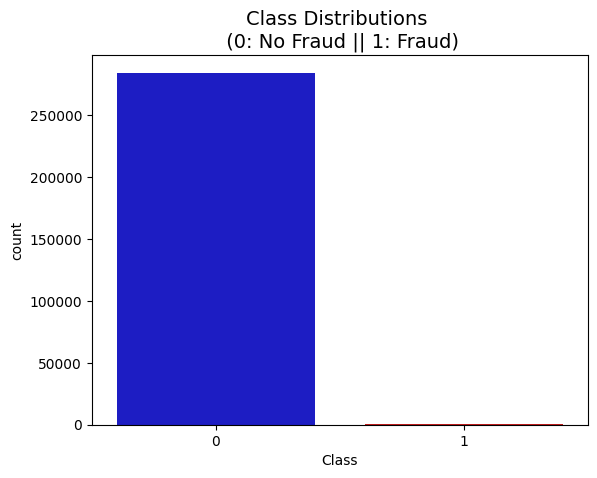

In [ ]:
colors = ["#0101DF", "#DF0101"]

# Especificamos explícitamente x='Class'
sns.countplot(x='Class', data=df, palette=colors)

plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
plt.show()

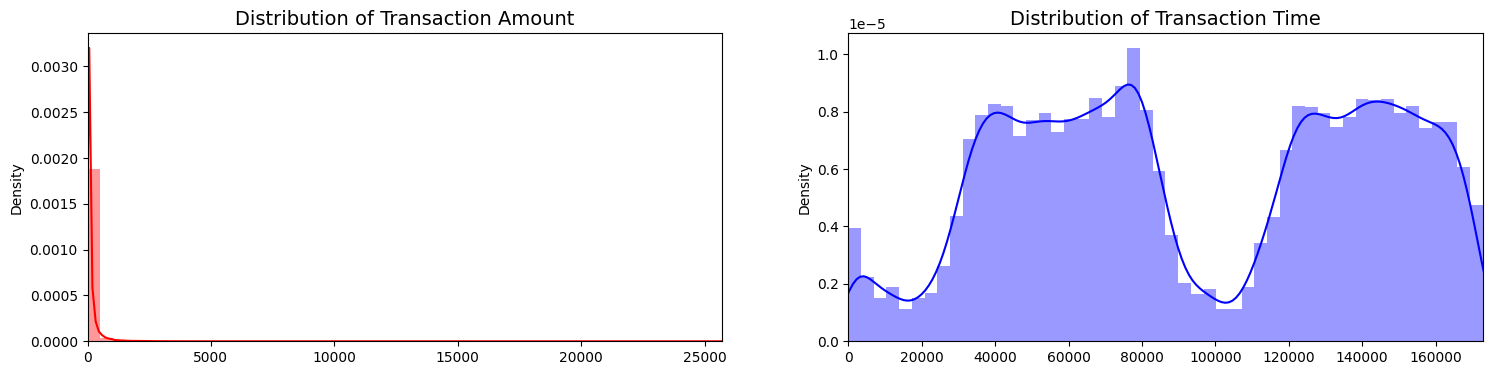

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

In [ ]:
# Dado que la mayoría de nuestros datos ya han sido escalados, debemos escalar las columnas que quedan por escalar (Cantidad y Tiempo)
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler es menos propenso a los valores atípicos.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [ ]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Amount and Time are Scaled!

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# 1. Limpieza de seguridad: Eliminamos filas con valores nulos (NaN) para evitar el ValueError
df.dropna(inplace=True)

# 2. Verificación de la distribución original
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

# 3. Definición de variables
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Configuración de StratifiedKFold (Estratificación)
# Usamos esto para mantener la proporción de fraude en cada partición
sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    # print("Train:", train_index, "Test:", test_index) # Opcional: imprimir índices
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# 5. Conversión a Arrays de NumPy
# Importante para que los modelos de Machine Learning procesen los datos eficientemente
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# 6. Verificación final de la distribución en Train y Test
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('-' * 100)
print('Distribución de etiquetas (debe ser similar a la original): \n')
print(f'Proporción en Entrenamiento: {train_counts_label / len(original_ytrain)}')
print(f'Proporción en Prueba: {test_counts_label / len(original_ytest)}')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset
----------------------------------------------------------------------------------------------------
Distribución de etiquetas (debe ser similar a la original): 

Proporción en Entrenamiento: [0.99827076 0.00172924]
Proporción en Prueba: [0.99827952 0.00172048]


In [ ]:
## Dado que nuestras clases están muy sesgadas, deberíamos hacerlas equivalentes para tener una distribución normal de las clases.
# Lets shuffle the data before creating the subsamples

df = df.sample(frac=1)

# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
142644,-0.216307,0.001868,1.213223,-0.521574,0.902561,-1.251709,-1.080423,-0.333691,-0.670100,0.047709,...,-0.046973,-0.033880,0.287816,-0.000762,0.171765,0.352623,-0.010610,0.072501,0.024686,0
152019,-0.293440,0.141273,-3.705856,4.107873,-3.803656,1.710314,-3.582466,1.469729,-9.621560,-11.913105,...,3.639603,-5.498772,2.941475,0.916236,-0.255504,-0.183835,-0.584539,-0.315484,-0.097223,1
210283,-0.296653,0.625278,2.136862,-0.029187,-2.375752,-0.216166,0.749858,-1.041072,0.588724,-0.325741,...,-0.310481,0.139995,0.469191,-0.119261,-0.779459,0.446154,0.276411,-0.095984,-0.100405,0
40525,-0.293440,-0.521811,1.159373,2.844795,-4.050680,4.777701,2.948980,-2.010361,1.744086,-0.410287,...,-0.059264,-0.176541,-0.433470,-0.529323,-0.597020,1.335954,0.547092,0.009979,0.160769,1
30100,0.539370,-0.574737,-3.218952,2.708535,-3.263042,1.361866,-1.645776,-1.852982,-3.069958,-1.796876,...,0.571654,1.807877,-0.890421,-0.325814,0.123040,-0.093014,0.232106,-0.310519,-0.745295,1


Distribution of the Classes in the subsample dataset
Class
0    0.5
1    0.5
Name: count, dtype: float64


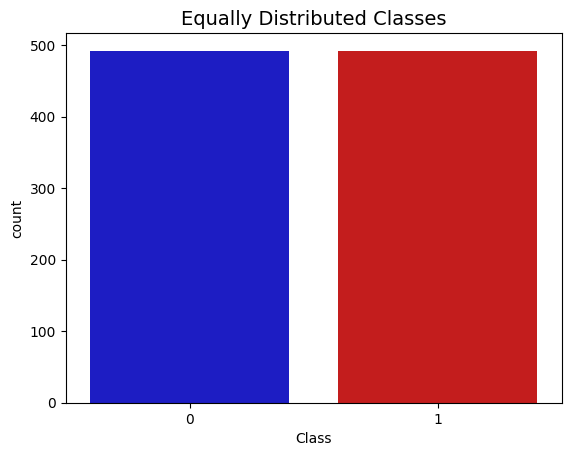

In [ ]:
print('Distribution of the Classes in the subsample dataset')
print(new_df['Class'].value_counts()/len(new_df))

# Corregimos especificando x='Class' y añadiendo hue para compatibilidad
sns.countplot(x='Class', data=new_df, palette=colors, hue='Class', legend=False)

plt.title('Equally Distributed Classes', fontsize=14)
plt.show()

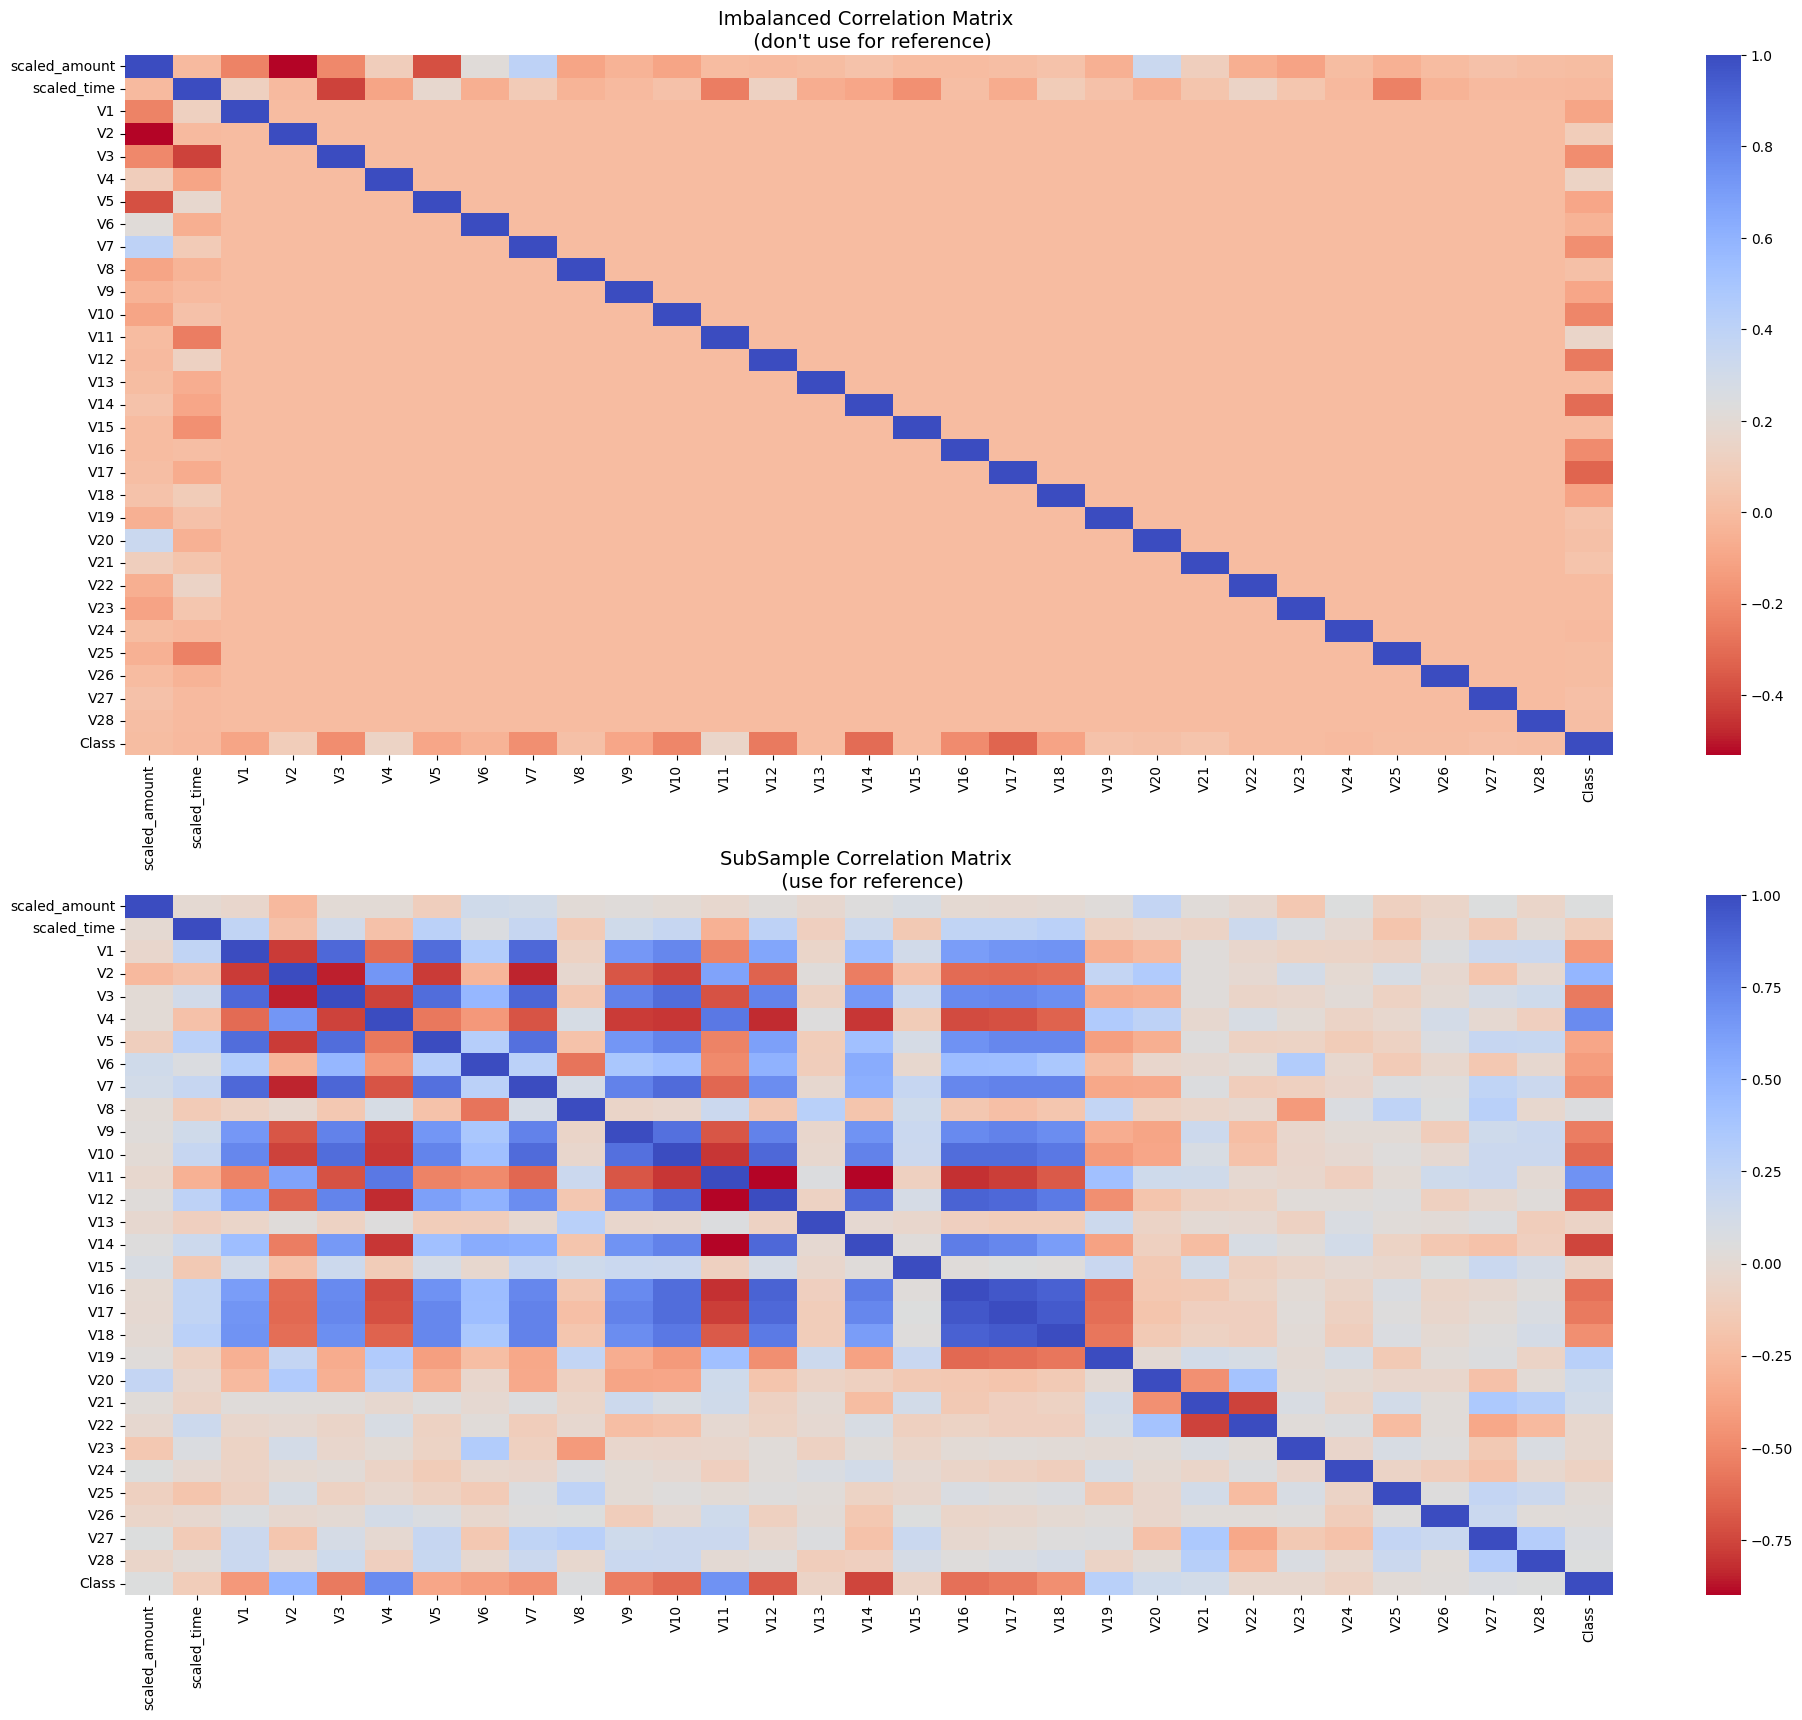

In [ ]:
# Make sure we use the subsample in our correlation

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

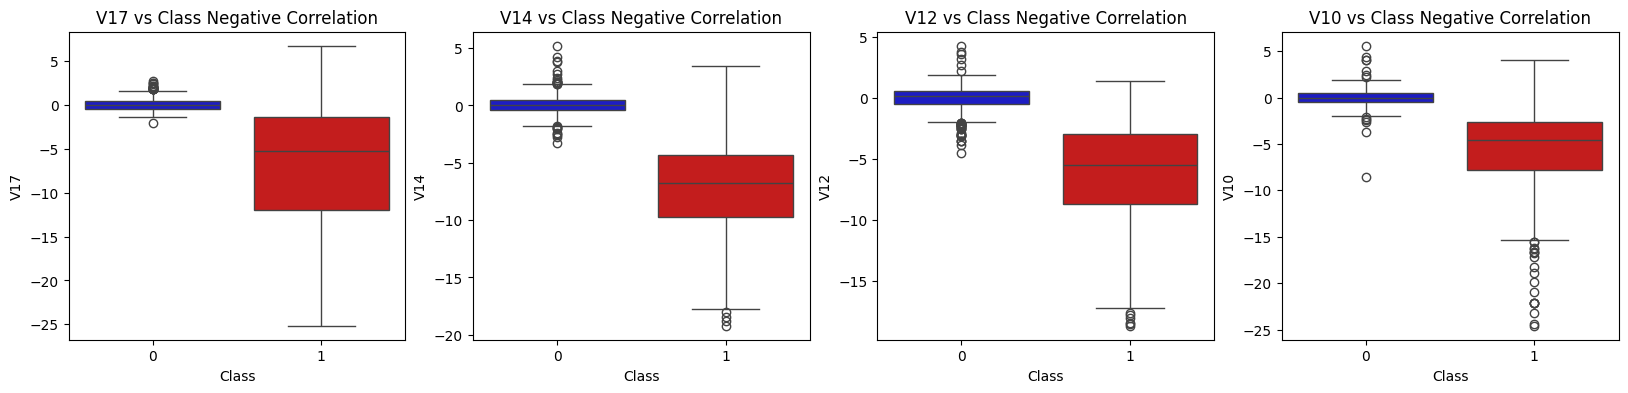

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)
sns.boxplot(x="Class", y="V17", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

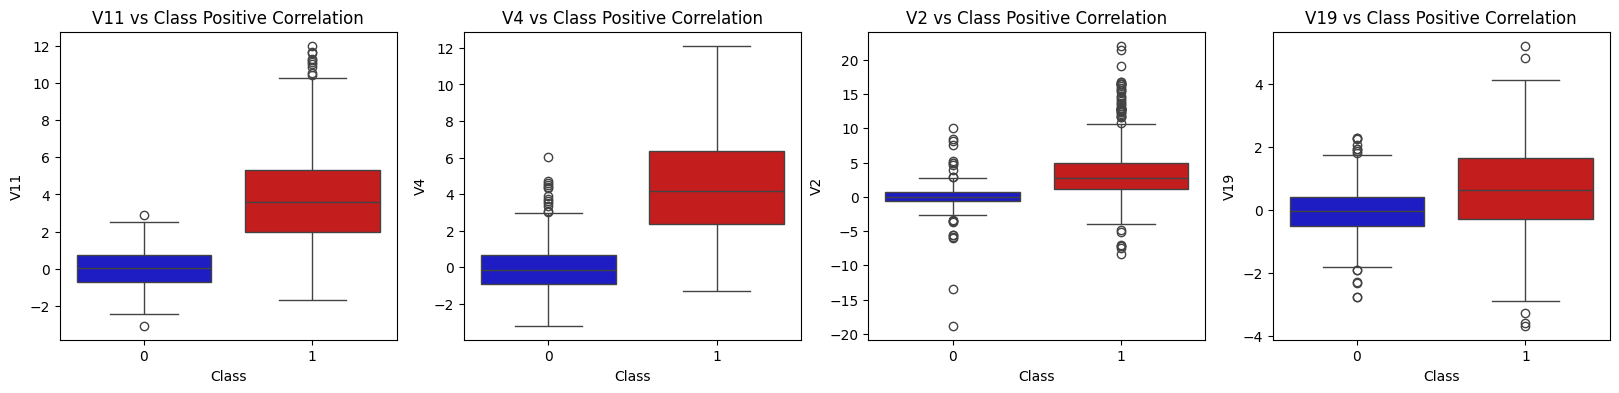

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

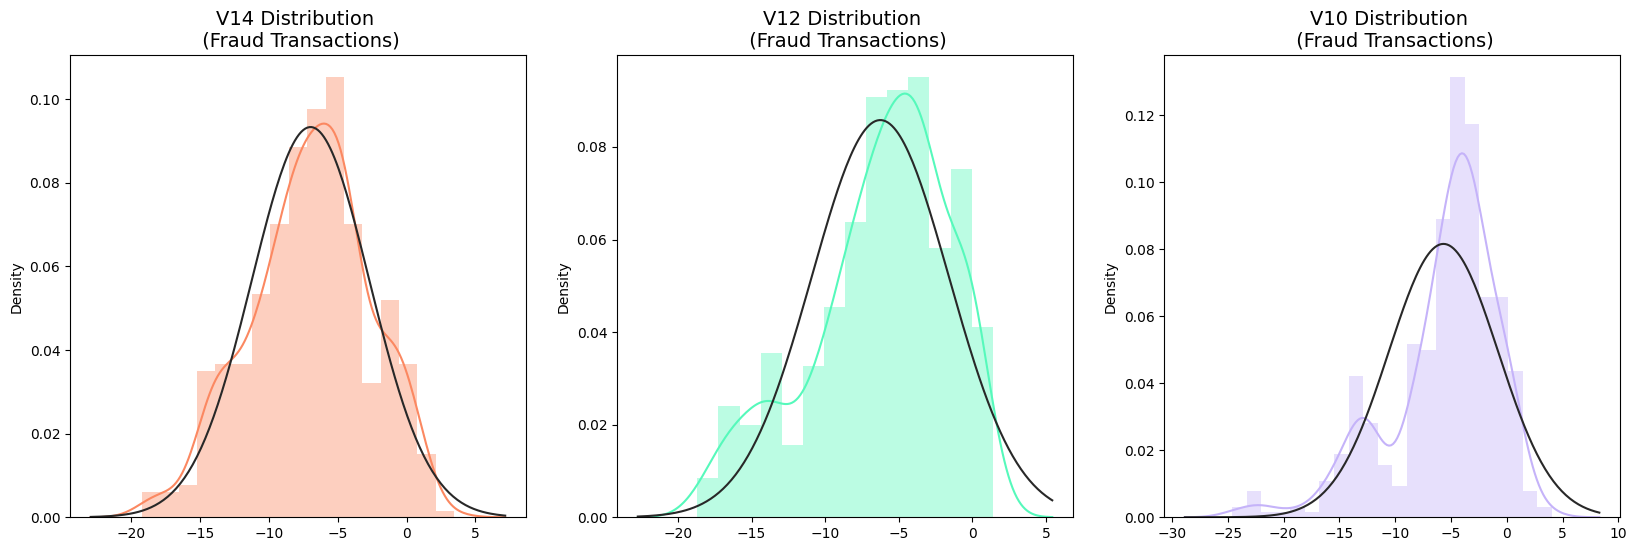

In [ ]:
from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist,ax=ax1, fit=norm, color='#FB8861')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)

v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist,ax=ax2, fit=norm, color='#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)

v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist,ax=ax3, fit=norm, color='#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()


In [ ]:
# # -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_df = new_df.drop(new_df[(new_df['V14'] > v14_upper) | (new_df['V14'] < v14_lower)].index)
print('----' * 44)

# -----> V12 removing outliers from fraud transactions
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V12'] > v12_upper) | (new_df['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))
print('----' * 44)


# Removing outliers V10 Feature
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))
new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_df)))

Quartile 25: -9.692722964972386 | Quartile 75: -4.282820849486865
iqr: 5.409902115485521
Cut Off: 8.114853173228282
V14 Lower: -17.807576138200666
V14 Upper: 3.8320323237414167
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[np.float64(-18.0499976898594), np.float64(-18.4937733551053), np.float64(-18.8220867423816), np.float64(-19.2143254902614)]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [np.float64(-18.6837146333443), np.float64(-18.4311310279993), np.float64(-18.0475965708216), np.float64(-18.5536970096458)]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 973
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V10 Lo

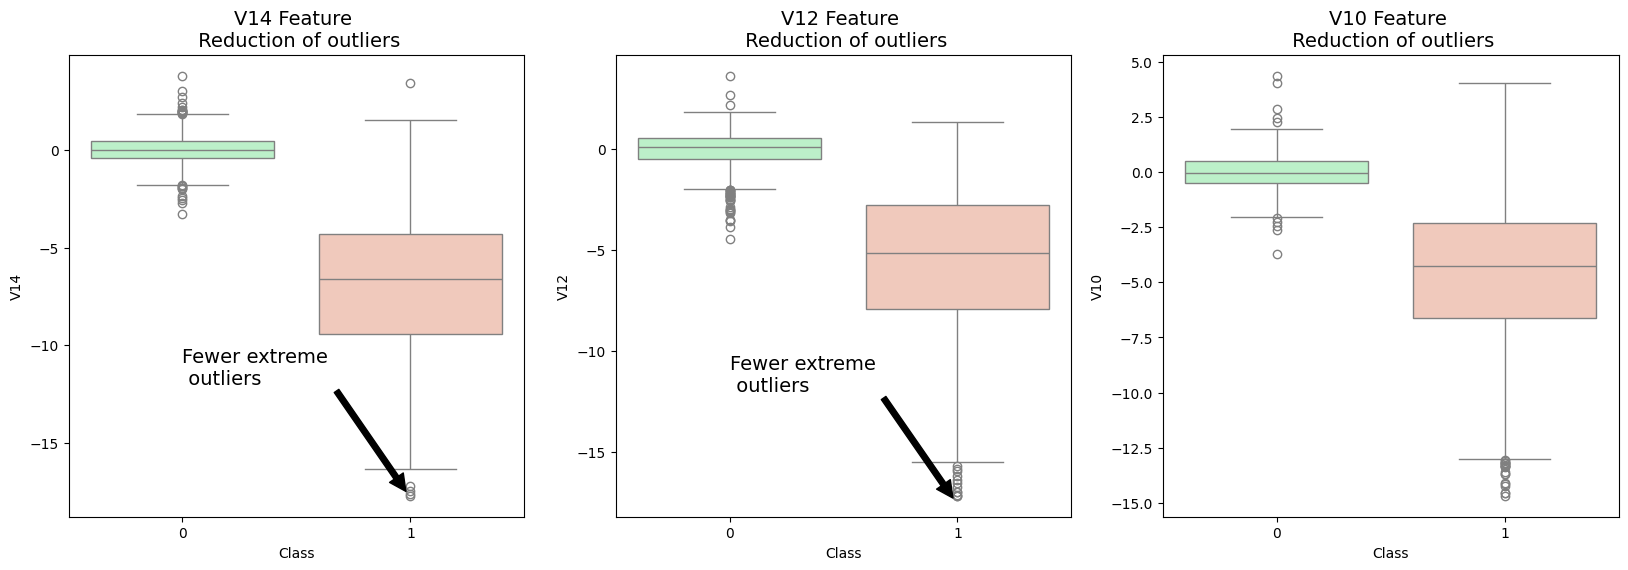

In [ ]:
f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x="Class", y="V14", data=new_df,ax=ax1, palette=colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize=14)
ax1.annotate('Fewer extreme \n outliers', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature 12
sns.boxplot(x="Class", y="V12", data=new_df, ax=ax2, palette=colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize=14)
ax2.annotate('Fewer extreme \n outliers', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)

# Feature V10
sns.boxplot(x="Class", y="V10", data=new_df, ax=ax3, palette=colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize=14)
ax3.annotate('Fewer extreme \n outliers', xy=(0.95, -16.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'),
            fontsize=14)


plt.show()

In [ ]:
# New_df is from the random undersample data (fewer instances)
X = new_df.drop('Class', axis=1)
y = new_df['Class']


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 9.6 s
PCA took 0.0086 s
Truncated SVD took 0.028 s


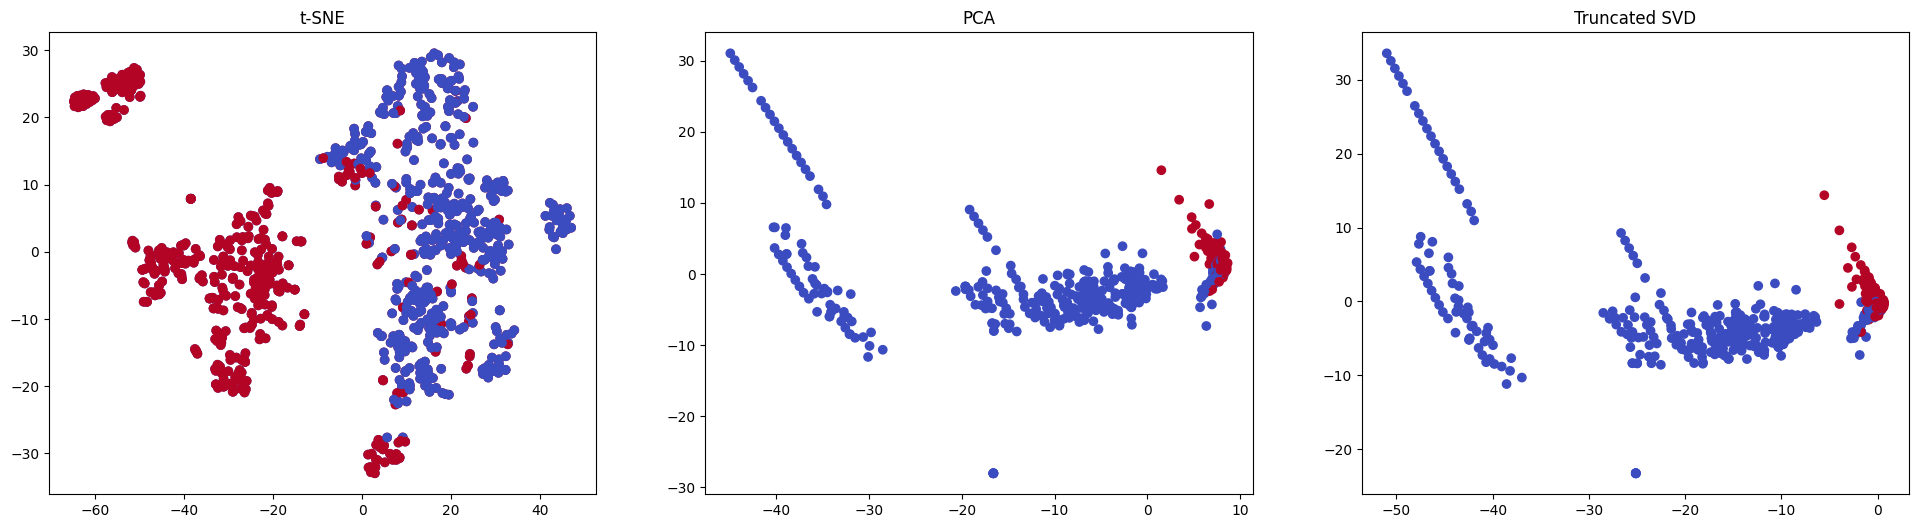

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# Gráfico para T-SNE
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraude')
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraude')
ax1.set_title('t-SNE')

# Gráfico para PCA
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm')
ax2.set_title('PCA')

# Gráfico para SVD
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm')
ax3.set_title('Truncated SVD')

plt.show()

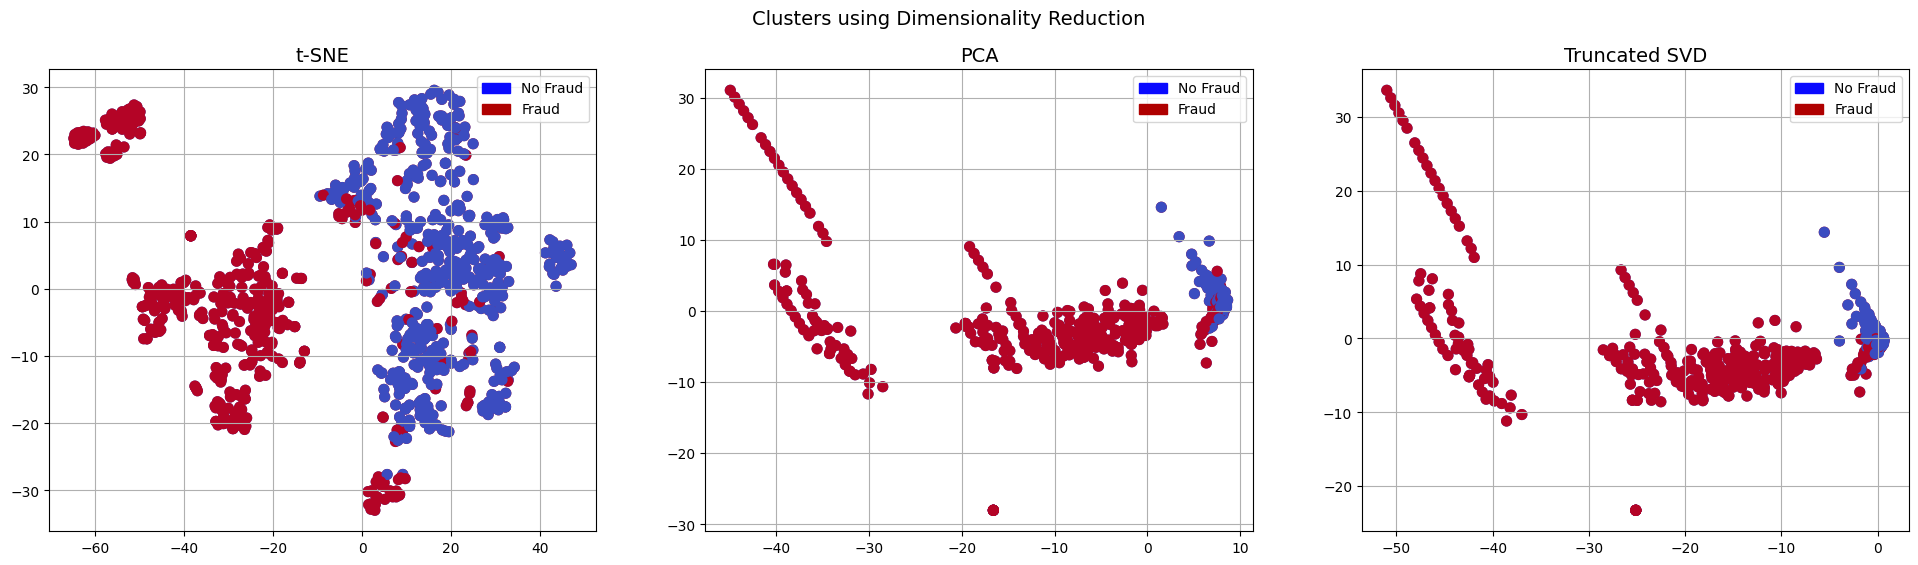

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

In [ ]:
# Undersampling before cross validating (prone to overfit)
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [ ]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

In [ ]:
# Wow our scores are getting even high scores even when applying cross validation.
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 93.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 94.0 % accuracy score
Classifiers:  SVC Has a training score of 94.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 91.0 % accuracy score


DBSCAN tomó: 0.01s
LOF tomó: 0.01s


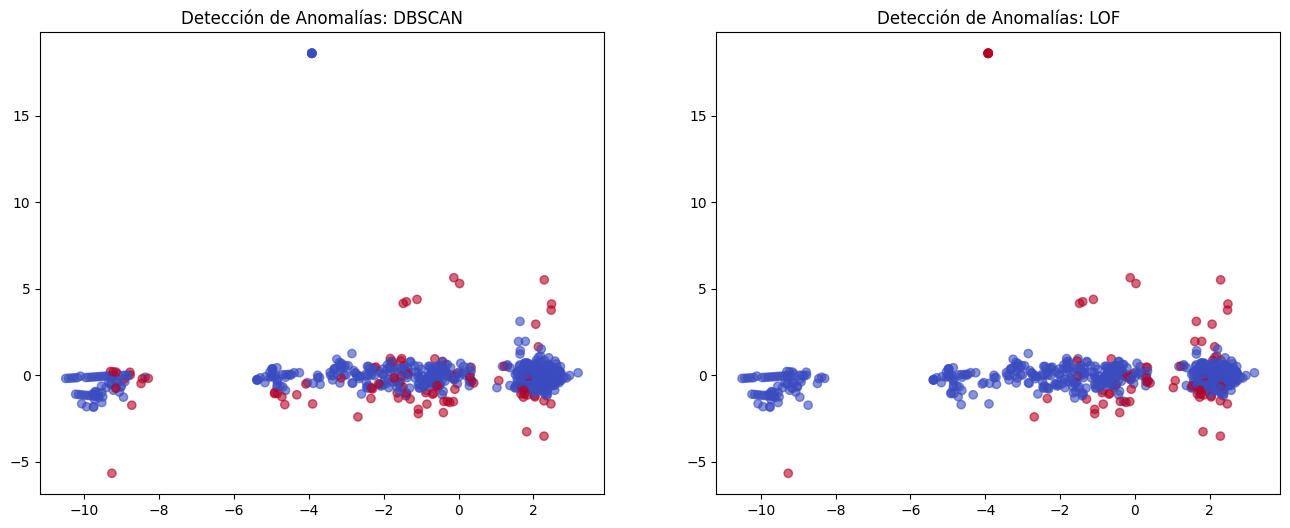


[Métricas DBSCAN]
              precision    recall  f1-score   support

           0       0.56      0.97      0.71       488
           1       0.85      0.19      0.31       457

    accuracy                           0.59       945
   macro avg       0.71      0.58      0.51       945
weighted avg       0.70      0.59      0.52       945


[Métricas LOF]
              precision    recall  f1-score   support

           0       0.53      0.93      0.68       488
           1       0.63      0.13      0.22       457

    accuracy                           0.54       945
   macro avg       0.58      0.53      0.45       945
weighted avg       0.58      0.54      0.45       945



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# --- PREPARACIÓN DE DATOS ---
# Usamos el dataset balanceado (new_df) para que el gráfico no sea ilegible

X = new_df.drop('Class', axis=1).values
y = new_df['Class'].values

# IMPORTANTE: Escalar los datos. DBSCAN y LOF se basan en distancias (Euclidianas).
# Si una variable tiene valores de 0-1 y otra de 0-1000, el modelo fallará.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# --- IMPLEMENTACIÓN DBSCAN ---
# eps: radio de vecindad. min_samples: puntos mínimos para ser un grupo.
t0 = time.time()
dbscan = DBSCAN(eps=3.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)
# En DBSCAN, -1 es ruido/anomalía. Lo mapeamos a 1 para comparar con 'Class'.
y_pred_dbscan = np.where(db_clusters == -1, 1, 0)
print(f"DBSCAN tomó: {time.time() - t0:.2f}s")

# --- IMPLEMENTACIÓN LOF ---
# n_neighbors: cuántos vecinos mirar. contamination: % esperado de anomalías.
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_lof = lof.fit_predict(X_scaled)

# En LOF, -1 es anomalía y 1 es normal. Mapeamos -1 a 1 y 1 a 0.
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)
print(f"LOF tomó: {time.time() - t0:.2f}s")

# --- VISUALIZACIÓN (PCA a 2D) ---
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico DBSCAN
ax1.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=y_pred_dbscan, cmap='coolwarm', alpha=0.6)
ax1.set_title('Detección de Anomalías: DBSCAN')

# Gráfico LOF
ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=y_pred_lof, cmap='coolwarm', alpha=0.6)
ax2.set_title('Detección de Anomalías: LOF')

plt.show()

# --- REPORTE DE MÉTRICAS ---

print("\n[Métricas DBSCAN]")
print(classification_report(y, y_pred_dbscan))

print("\n[Métricas LOF]")
print(classification_report(y, y_pred_lof))

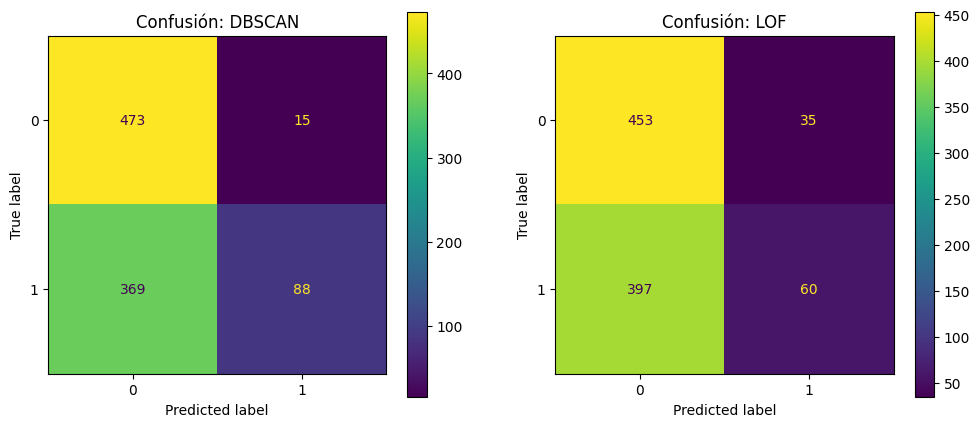

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz para DBSCAN
cm_db = confusion_matrix(y, y_pred_dbscan)
ConfusionMatrixDisplay(cm_db).plot(ax=ax[0])
ax[0].set_title('Confusión: DBSCAN')

# Matriz para LOF
cm_lof = confusion_matrix(y, y_pred_lof)
ConfusionMatrixDisplay(cm_lof).plot(ax=ax[1])
ax[1].set_title('Confusión: LOF')

plt.show()

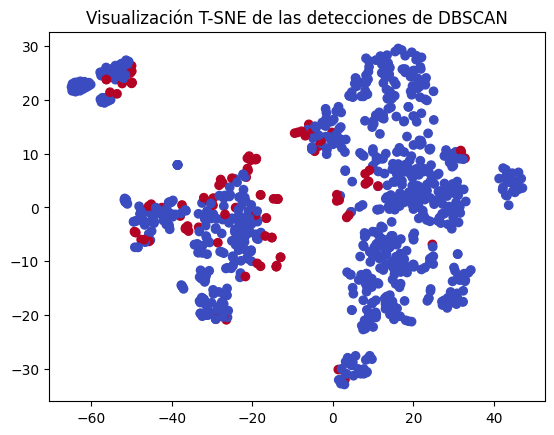

In [ ]:
# Si ya tienes X_reduced_tsne calculado:
plt.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y_pred_dbscan, cmap='coolwarm')
plt.title('Visualización T-SNE de las detecciones de DBSCAN')
plt.show()

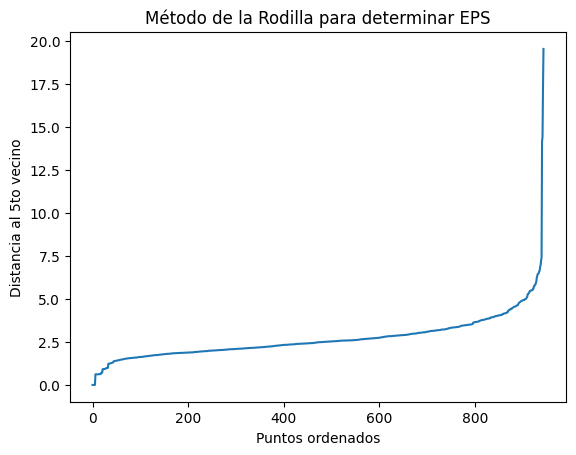

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Calculamos la distancia al vecino más cercano (k=5 porque min_samples=5)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenamos y graficamos
distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.title('Método de la Rodilla para determinar EPS')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5to vecino')
plt.show()

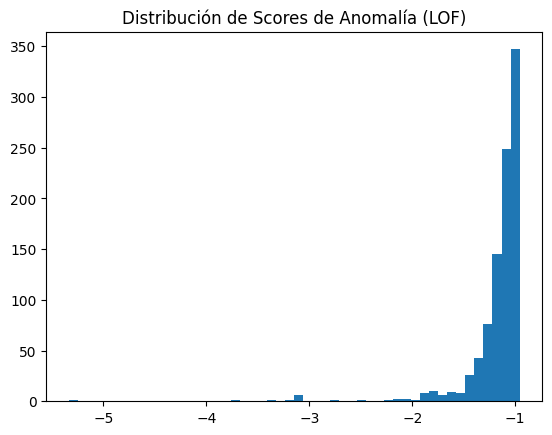

In [ ]:
# Los scores de LOF (mientras más negativos, más anómalos)
lof_scores = lof.negative_outlier_factor_
plt.hist(lof_scores, bins=50)
plt.title('Distribución de Scores de Anomalía (LOF)')
plt.show()

Iniciando Gran Comparativa de 10 iteraciones...
Iteración 1 finalizada.
Iteración 2 finalizada.
Iteración 3 finalizada.
Iteración 4 finalizada.
Iteración 5 finalizada.
Iteración 6 finalizada.
Iteración 7 finalizada.
Iteración 8 finalizada.
Iteración 9 finalizada.
Iteración 10 finalizada.


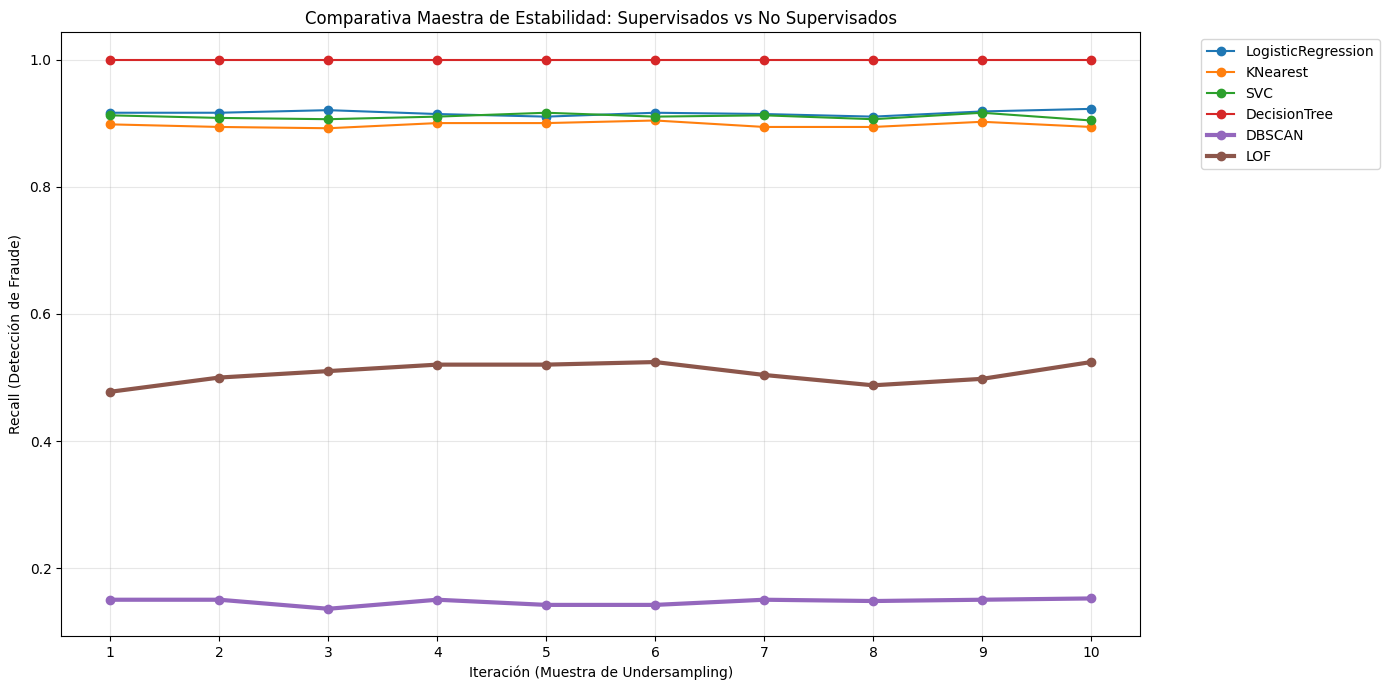


--- RESUMEN DE RENDIMIENTO (ORDENADO POR RECALL PROMEDIO) ---
                        mean       std
DecisionTree        1.000000  0.000000
LogisticRegression  0.916260  0.003927
SVC                 0.910569  0.004176
KNearest            0.897561  0.004198
LOF                 0.506707  0.016120
DBSCAN              0.147358  0.005270


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import recall_score

# --- CONFIGURACIÓN ---
n_iteraciones = 10
# Diccionario para guardar todos los resultados de Recall
resultados = {
    "LogisticRegression": [],
    "KNearest": [],
    "SVC": [],
    "DecisionTree": [],
    "DBSCAN": [],
    "LOF": []
}

# Separar datos originales de Kaggle
fraudes = df[df['Class'] == 1]
no_fraudes = df[df['Class'] == 0]

print(f"Iniciando Gran Comparativa de 10 iteraciones...")

for i in range(n_iteraciones):
    # 1. Undersampling (Balanceo 50/50)
    no_fraudes_muestra = no_fraudes.sample(n=len(fraudes), random_state=i)
    df_iter = pd.concat([fraudes, no_fraudes_muestra])
    df_iter = shuffle(df_iter, random_state=i)

    X_iter = df_iter.drop('Class', axis=1).values
    y_true = df_iter['Class'].values

    # 2. Escalado (Crítico para KNN, SVC, DBSCAN y LOF)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_iter)

    # --- A. ENTRENAMIENTO SUPERVISADOS ---
    # Logística
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_scaled, y_true)
    resultados["LogisticRegression"].append(recall_score(y_true, lr.predict(X_scaled)))

    # KNN
    knn = KNeighborsClassifier()
    knn.fit(X_scaled, y_true)
    resultados["KNearest"].append(recall_score(y_true, knn.predict(X_scaled)))

    # SVC
    svc = SVC()
    svc.fit(X_scaled, y_true)
    resultados["SVC"].append(recall_score(y_true, svc.predict(X_scaled)))

    # Decision Tree
    dt = DecisionTreeClassifier()
    dt.fit(X_scaled, y_true)
    resultados["DecisionTree"].append(recall_score(y_true, dt.predict(X_scaled)))

    # --- B. EJECUCIÓN NO SUPERVISADOS ---
    # DBSCAN
    db = DBSCAN(eps=3.5, min_samples=5)
    db_pred = db.fit_predict(X_scaled)
    y_db = np.where(db_pred == -1, 1, 0)
    resultados["DBSCAN"].append(recall_score(y_true, y_db))

    # LOF
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.5)
    lof_pred = lof.fit_predict(X_scaled)
    y_lof = np.where(lof_pred == -1, 1, 0)
    resultados["LOF"].append(recall_score(y_true, y_lof))

    print(f"Iteración {i+1} finalizada.")

# --- VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(14, 7))
for modelo, scores in resultados.items():
    # Usamos diferentes grosores para resaltar Supervisados vs No Supervisados
    ancho = 3 if modelo in ["DBSCAN", "LOF"] else 1.5
    plt.plot(range(1, 11), scores, label=modelo, linewidth=ancho, marker='o')

plt.title('Comparativa Maestra de Estabilidad: Supervisados vs No Supervisados')
plt.xlabel('Iteración (Muestra de Undersampling)')
plt.ylabel('Recall (Detección de Fraude)')
plt.xticks(range(1, 11))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen Estadístico Final
res_df = pd.DataFrame(resultados).agg(['mean', 'std']).T
print("\n--- RESUMEN DE RENDIMIENTO (ORDENADO POR RECALL PROMEDIO) ---")
print(res_df.sort_values(by='mean', ascending=False))

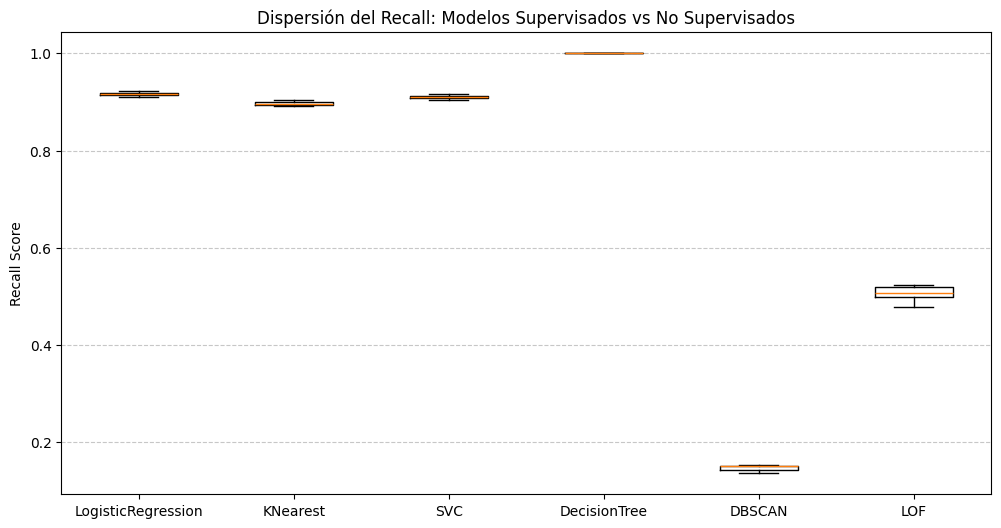

In [ ]:
# Crear el Boxplot para comparar la dispersión del Recall
plt.figure(figsize=(12, 6))
plt.boxplot([resultados[m] for m in resultados.keys()], labels=resultados.keys())
plt.title('Dispersión del Recall: Modelos Supervisados vs No Supervisados')
plt.ylabel('Recall Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Iniciando Simulación de 30 iteraciones...
Progreso: 5/30 iteraciones completadas...
Progreso: 10/30 iteraciones completadas...
Progreso: 15/30 iteraciones completadas...
Progreso: 20/30 iteraciones completadas...
Progreso: 25/30 iteraciones completadas...
Progreso: 30/30 iteraciones completadas...

¡Simulación finalizada en 6.61 segundos!


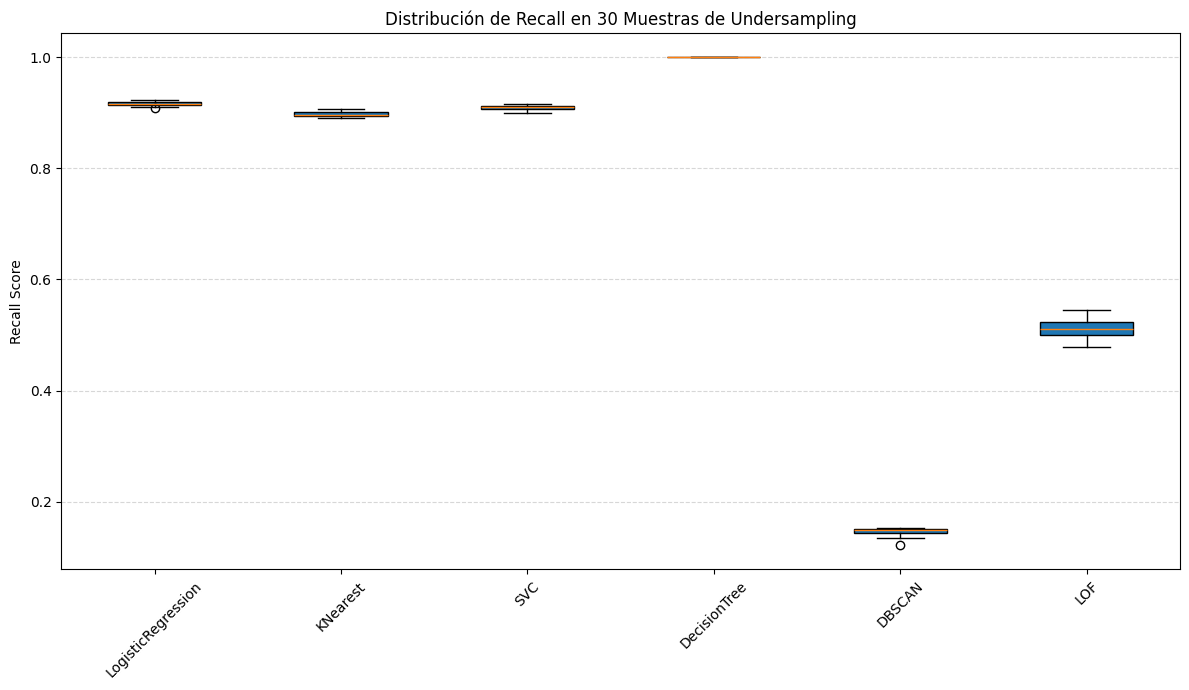


--- RESUMEN ESTADÍSTICO DE ROBUSTEZ ---
                        mean       std       min       max
DecisionTree        1.000000  0.000000  1.000000  1.000000
LogisticRegression  0.916192  0.003568  0.908537  0.922764
SVC                 0.909688  0.004488  0.900407  0.916667
KNearest            0.897493  0.004970  0.890244  0.906504
LOF                 0.510501  0.015969  0.477642  0.544715
DBSCAN              0.146409  0.006526  0.121951  0.152439


In [ ]:
#Análisis de Robustez Extrema (30 Iteraciones)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import recall_score

# --- CONFIGURACIÓN ---
n_iteraciones = 30  # <--- Subimos a 30 para rigor estadístico
resultados = {
    "LogisticRegression": [],
    "KNearest": [],
    "SVC": [],
    "DecisionTree": [],
    "DBSCAN": [],
    "LOF": []
}

# Separar datos originales
fraudes = df[df['Class'] == 1]
no_fraudes = df[df['Class'] == 0]

print(f"Iniciando Simulación de 30 iteraciones...")
start_total = time.time()

for i in range(n_iteraciones):
    iter_start = time.time()

    # 1. Undersampling Aleatorio (Cambiamos la semilla en cada vuelta con i)
    no_fraudes_muestra = no_fraudes.sample(n=len(fraudes), random_state=i)
    df_iter = pd.concat([fraudes, no_fraudes_muestra])
    df_iter = shuffle(df_iter, random_state=i)

    X_iter = df_iter.drop('Class', axis=1).values
    y_true = df_iter['Class'].values

    # 2. Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_iter)

    # --- Evaluación de Modelos ---
    # Supervisados
    lr = LogisticRegression(max_iter=1000).fit(X_scaled, y_true)
    resultados["LogisticRegression"].append(recall_score(y_true, lr.predict(X_scaled)))

    knn = KNeighborsClassifier().fit(X_scaled, y_true)
    resultados["KNearest"].append(recall_score(y_true, knn.predict(X_scaled)))

    svc = SVC().fit(X_scaled, y_true)
    resultados["SVC"].append(recall_score(y_true, svc.predict(X_scaled)))

    dt = DecisionTreeClassifier().fit(X_scaled, y_true)
    resultados["DecisionTree"].append(recall_score(y_true, dt.predict(X_scaled)))

    # No Supervisados
    db = DBSCAN(eps=3.5, min_samples=5).fit_predict(X_scaled)
    resultados["DBSCAN"].append(recall_score(y_true, np.where(db == -1, 1, 0)))

    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.5).fit_predict(X_scaled)
    resultados["LOF"].append(recall_score(y_true, np.where(lof == -1, 1, 0)))

    if (i+1) % 5 == 0:
        print(f"Progreso: {i+1}/{n_iteraciones} iteraciones completadas...")

end_total = time.time()
print(f"\n¡Simulación finalizada en {end_total - start_total:.2f} segundos!")

# --- VISUALIZACIÓN FINAL (BOXPLOT) ---
# El Boxplot es mejor que la línea cuando hay muchas iteraciones
plt.figure(figsize=(12, 7))
plt.boxplot([resultados[m] for m in resultados.keys()], labels=resultados.keys(), patch_artist=True)
plt.title(f'Distribución de Recall en {n_iteraciones} Muestras de Undersampling')
plt.ylabel('Recall Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- REPORTE ESTADÍSTICO ---
res_df = pd.DataFrame(resultados).agg(['mean', 'std', 'min', 'max']).T
print("\n--- RESUMEN ESTADÍSTICO DE ROBUSTEZ ---")
print(res_df.sort_values(by='mean', ascending=False))

In [ ]:
#Código para probar con el Dataset Completo
import pandas as pd

df = pd.read_csv('creditcard.csv')

# 2. Verificar que se cargó
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
# 1. Preparamos el dataset completo (Original)
# Supongamos que 'df' es tu dataframe con los 284k registros
X_full = df.drop('Class', axis=1).values
y_full = df['Class'].values

# Importante: El escalador debe ser el mismo que usaste en el entrenamiento
X_full_scaled = scaler.transform(X_full)

# 2. Probamos el mejor modelo supervisado (ej. Logistic Regression)
y_pred_full = lr.predict(X_full_scaled)

# 3. Probamos un No Supervisado (ej. DBSCAN)
# ¡Cuidado! DBSCAN en 284k filas puede tardar mucho.
# Si tu PC es lenta, mejor hazlo solo con los supervisados.
db_full = dbscan.fit_predict(X_full_scaled)
y_db_full = np.where(db_full == -1, 1, 0)

# 4. Reporte de la Realidad
from sklearn.metrics import classification_report, confusion_matrix

print("--- EVALUACIÓN EN DATASET COMPLETO (LA PRUEBA DE FUEGO) ---")
print(classification_report(y_full, y_pred_full))

# Matriz de Confusión del dataset completo
cm = confusion_matrix(y_full, y_pred_full)
print("Matriz de Confusión:\n", cm)

Dataset cargado con 284807 filas y 31 columnas.
--- EVALUACIÓN EN DATASET COMPLETO (LA PRUEBA DE FUEGO) ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00    284315
           1       0.00      1.00      0.00       492

    accuracy                           0.00    284807
   macro avg       0.50      0.50      0.00    284807
weighted avg       1.00      0.00      0.00    284807

Matriz de Confusión:
 [[    32 284283]
 [     0    492]]


--- EVALUANDO EN 284,807 TRANSACCIONES ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98    284315
      Fraude       0.05      0.93      0.09       492

    accuracy                           0.97    284807
   macro avg       0.52      0.95      0.53    284807
weighted avg       1.00      0.97      0.98    284807



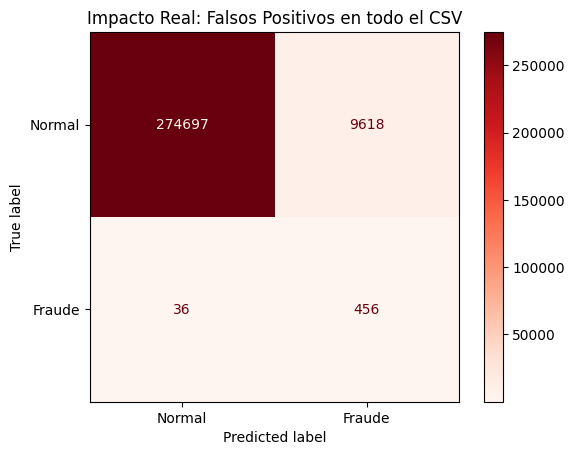

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- PASO 1: DEFINIR EL ESCALADOR GLOBAL ---
scaler = StandardScaler()

# 1.1 Escalamos el dataset completo de una vez (para evitar NameError luego)
X_full = df.drop('Class', axis=1).values
y_full = df['Class'].values
X_full_scaled = scaler.fit_transform(X_full) # Aquí se define 'scaler' y 'X_full_scaled'

# --- PASO 2: EL MEJOR MODELO (EJEMPLO LOGÍSTICA) ---
# Entrenamos un modelo final con una muestra balanceada para usarlo en la prueba total
fraudes = df[df['Class'] == 1]
no_fraudes = df[df['Class'] == 0].sample(n=len(fraudes), random_state=42)
df_balanced = pd.concat([fraudes, no_fraudes])

X_train = df_balanced.drop('Class', axis=1).values
y_train = df_balanced['Class'].values
X_train_scaled = scaler.transform(X_train)

# Entrenamos el modelo final
modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_train_scaled, y_train)

# --- PASO 3: LA PRUEBA DE FUEGO (DATASET COMPLETO) ---
print("--- EVALUANDO EN 284,807 TRANSACCIONES ---")
y_pred_full = modelo_final.predict(X_full_scaled)

# Reporte de métricas reales
print(classification_report(y_full, y_pred_full, target_names=['Normal', 'Fraude']))

# Matriz de Confusión Visual
cm = confusion_matrix(y_full, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap='Reds')
import matplotlib.pyplot as plt
plt.title('Impacto Real: Falsos Positivos en todo el CSV')
plt.show()

Dataset recargado: 284807 filas y 31 columnas.
Modelo          | Recall     | Precisión  | Falsos Positivos
-----------------------------------------------------------------
Logística       | 0.9248     | 0.2155     | 1656
DBSCAN          | 0.6992     | 0.0984     | 3152
LOF             | 0.0264     | 0.0264     | 479


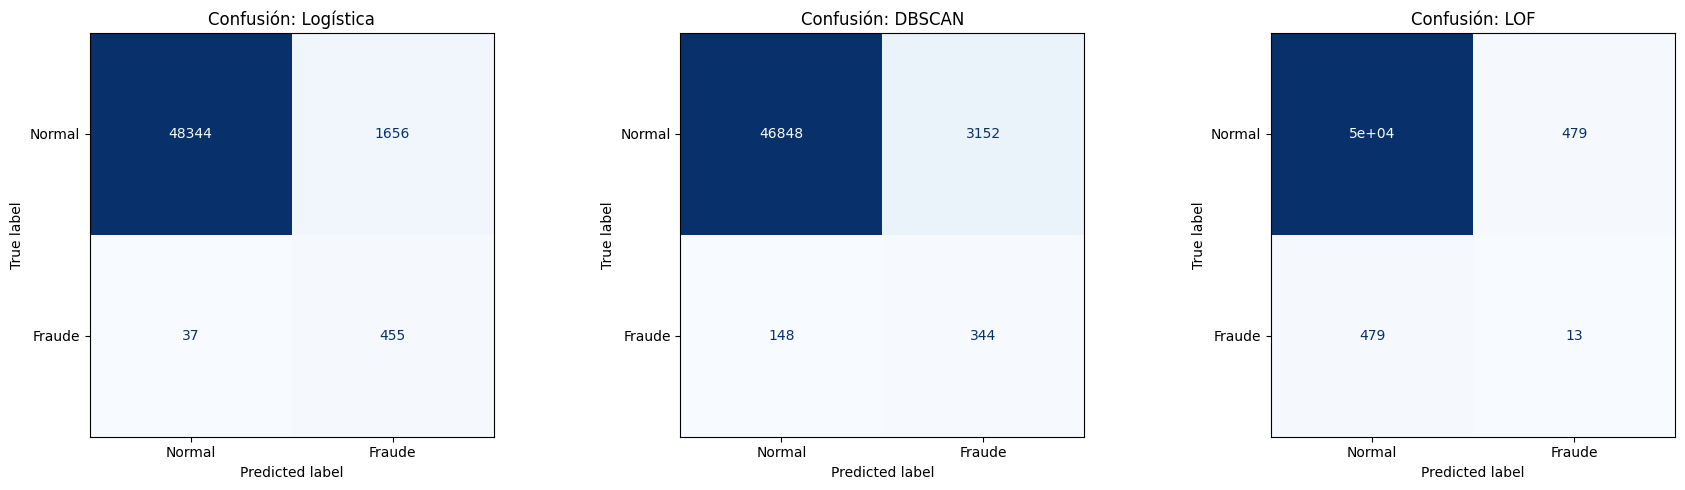

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

import pandas as pd

# Asegúrate de que el nombre del archivo coincida con el que subiste a Colab
df = pd.read_csv('creditcard.csv')

# Verificamos que cargó bien
print(f"Dataset recargado: {df.shape[0]} filas y {df.shape[1]} columnas.")

# --- PASO 1: Preparación del Dataset Optimizada ---
# Separamos las clases para asegurar que conservamos los fraudes
fraudes_reales = df[df['Class'] == 1]
normales_reales = df[df['Class'] == 0]

# Tomamos una muestra de 50,000 normales para no saturar la RAM
# pero mantenemos los 492 fraudes intactos.
normales_muestra = normales_reales.sample(n=50000, random_state=42)
df_evaluacion = pd.concat([fraudes_reales, normales_muestra]).sample(frac=1, random_state=42)

# Ahora trabajamos con df_evaluacion (aprox 50,492 filas)
X_eval = df_evaluacion.drop('Class', axis=1).values
y_eval = df_evaluacion['Class'].values

scaler = StandardScaler()
X_eval_scaled = scaler.fit_transform(X_eval)

# --- PASO 2: Regresión Logística (Supervisado) ---
# Entrenamos con un undersampling pequeño como antes
no_fraudes_train = normales_reales.sample(len(fraudes_reales), random_state=42)
df_train = pd.concat([fraudes_reales, no_fraudes_train])
X_train_scaled = scaler.transform(df_train.drop('Class', axis=1).values)
y_train = df_train['Class'].values

lr = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_eval_scaled)

# --- PASO 3: DBSCAN (No Supervisado) ---
# Con 50k puntos, esto debería tardar unos 30-60 segundos sin romper la RAM
dbscan = DBSCAN(eps=3.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_eval_scaled)
y_pred_dbscan = np.where(db_clusters == -1, 1, 0)

# --- PASO 4: LOF (No Supervisado) ---
# Ajustamos la contaminación a la nueva proporción (fraudes / total_muestra)
nueva_contaminacion = len(fraudes_reales) / len(df_evaluacion)
lof = LocalOutlierFactor(n_neighbors=20, contamination=nueva_contaminacion)
lof_clusters = lof.fit_predict(X_eval_scaled)
y_pred_lof = np.where(lof_clusters == -1, 1, 0)

# --- PASO 5: Comparativa ---
modelos = {
    "Logística": y_pred_lr,
    "DBSCAN": y_pred_dbscan,
    "LOF": y_pred_lof
}


print(f"{'Modelo':<15} | {'Recall':<10} | {'Precisión':<10} | {'Falsos Positivos'}")
print("-" * 65)

for nombre, predicho in modelos.items():
    rec = recall_score(y_eval, predicho)
    prec = precision_score(y_eval, predicho)
    # Obtenemos los Falsos Positivos directamente de la matriz
    cm = confusion_matrix(y_eval, predicho)
    fp = cm[0][1]

    # FORMATO CORREGIDO: {valor:<espacio.decimales}
    print(f"{nombre:<15} | {rec:<10.4f} | {prec:<10.4f} | {fp}")

# --- PASO 6: Gráfico de Matrices de Confusión ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (nombre, predicho) in enumerate(modelos.items()):
    cm = confusion_matrix(y_eval, predicho)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusión: {nombre}')

plt.tight_layout()
plt.show()

Modelo (50/50)  | Recall     | Precisión  | Falsos Positivos
-----------------------------------------------------------------
Logística       | 0.9187     | 0.9805     | 9
DBSCAN          | 0.1585     | 0.8387     | 15
LOF             | 0.5142     | 0.5142     | 239


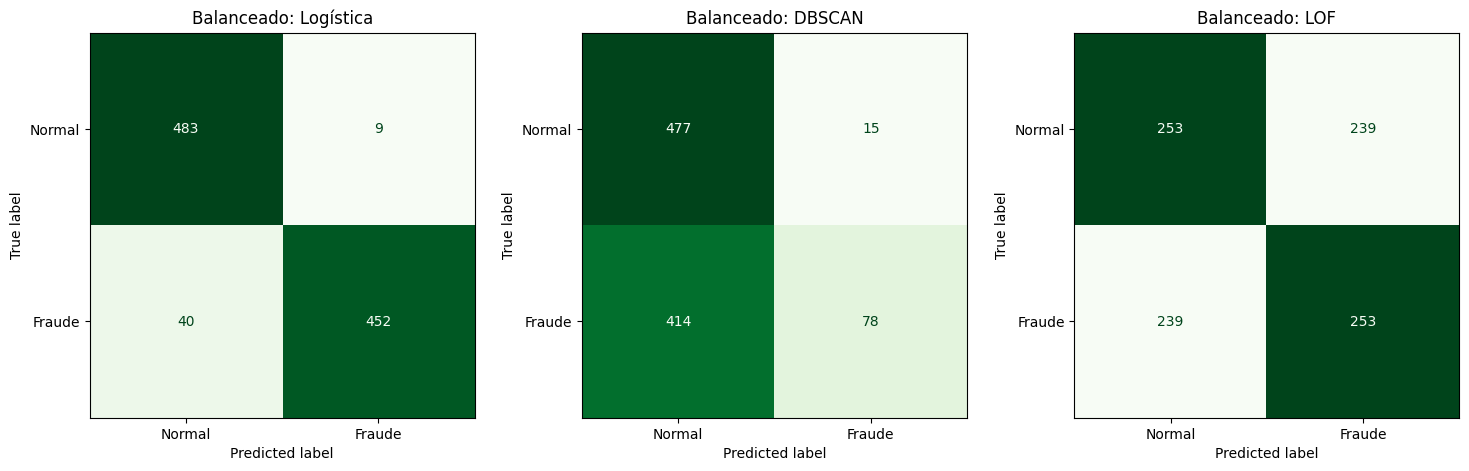

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

# --- PASO 1: Crear el Dataset Balanceado (50/50) ---
fraudes = df[df['Class'] == 1]
normales_sample = df[df['Class'] == 0].sample(len(fraudes), random_state=42)
df_new = pd.concat([fraudes, normales_sample]).sample(frac=1, random_state=42)

X_new = df_new.drop('Class', axis=1).values
y_new = df_new['Class'].values

scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)

# --- PASO 2: Entrenar y Predecir ---

# 1. Logística
lr_bal = LogisticRegression(max_iter=1000).fit(X_new_scaled, y_new)
y_pred_lr = lr_bal.predict(X_new_scaled)

# 2. DBSCAN (Ajustamos eps para este espacio reducido)
dbscan_bal = DBSCAN(eps=3.5, min_samples=5)
db_clusters = dbscan_bal.fit_predict(X_new_scaled)
y_pred_dbscan = np.where(db_clusters == -1, 1, 0)

# 3. LOF (Contaminación 0.5 porque es 50/50)
lof_bal = LocalOutlierFactor(n_neighbors=20, contamination=0.5)
y_pred_lof = np.where(lof_bal.fit_predict(X_new_scaled) == -1, 1, 0)

# --- PASO 3: Resultados ---
modelos_bal = {"Logística": y_pred_lr, "DBSCAN": y_pred_dbscan, "LOF": y_pred_lof}

print(f"{'Modelo (50/50)':<15} | {'Recall':<10} | {'Precisión':<10} | {'Falsos Positivos'}")
print("-" * 65)

for nombre, pred in modelos_bal.items():
    rec = recall_score(y_new, pred)
    prec = precision_score(y_new, pred)
    fp = confusion_matrix(y_new, pred)[0][1]
    print(f"{nombre:<15} | {rec:<10.4f} | {prec:<10.4f} | {fp}")

# Gráfico de Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (nombre, pred) in enumerate(modelos_bal.items()):
    cm = confusion_matrix(y_new, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    axes[i].set_title(f'Balanceado: {nombre}')
plt.show()

In [ ]:
#ANALISIS PLUS


Dataset cargado: 284807 filas.
Iniciando búsqueda de mejores parámetros (2-3 min)...
¡Modelos optimizados con éxito!

Modelo          | CV Score Promedio   
----------------------------------------
Logística       | 0.9441
K-Neighbors     | 0.9451
SVC             | 0.9431
Árbol           | 0.9258


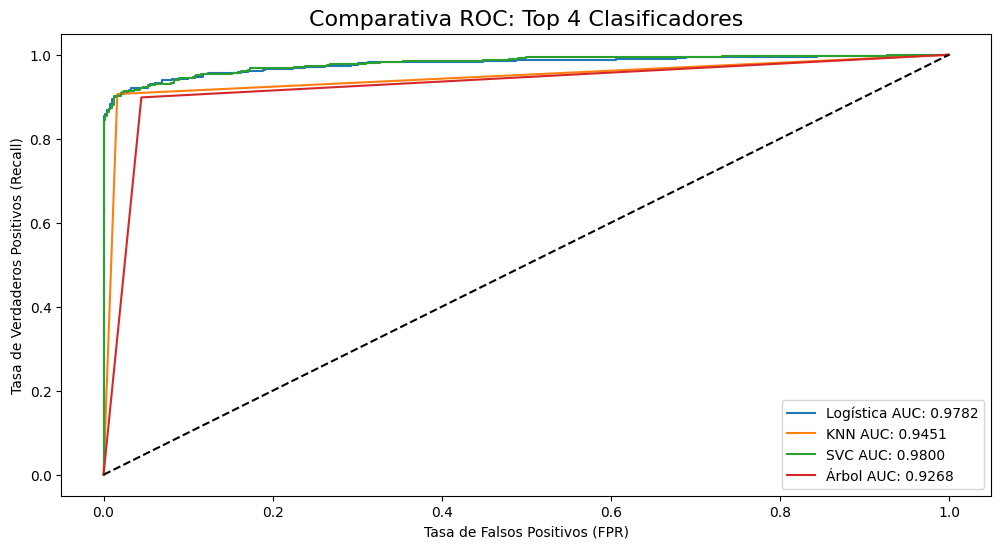

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# 1. CARGA DE DATOS
try:
    df = pd.read_csv('creditcard.csv')
    print(f"Dataset cargado: {df.shape[0]} filas.")
except:
    print("Error: Sube el archivo 'creditcard.csv' a la carpeta de Colab.")

# 2. ESCALADO CORREGIDO (Nombres con Mayúscula)
scaler = StandardScaler()

# Usamos 'Amount' y 'Time' con Mayúscula inicial
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Borramos las originales para no duplicar información
df.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# 3. CREACIÓN DEL DATASET BALANCEADO (Submuestreo Aleatorio)
fraudes = df[df['Class'] == 1]
normales = df[df['Class'] == 0].sample(len(fraudes), random_state=42)
df_new = pd.concat([fraudes, normales]).sample(frac=1, random_state=42)

X_train = df_new.drop('Class', axis=1)
y_train = df_new['Class']

# 4. OPTIMIZACIÓN CON GRIDSEARCHCV
print("Iniciando búsqueda de mejores parámetros (2-3 min)...")

# Logistic Regression
log_reg_params = {"penalty": ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log_reg = GridSearchCV(LogisticRegression(max_iter=1000), log_reg_params).fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_

# KNears
knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params).fit(X_train, y_train)
knears_neighbors = grid_knears.best_estimator_

# SVC (Se eliminó 'probability=True' para ganar velocidad, usa decision_function)
svc_params = {'C': [0.5, 0.8, 1], 'kernel': ['rbf', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params).fit(X_train, y_train)
svc = grid_svc.best_estimator_

# DecisionTree
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params).fit(X_train, y_train)
tree_clf = grid_tree.best_estimator_

print("¡Modelos optimizados con éxito!")

# 5. VALIDACIÓN CRUZADA
modelos = {
    "Logística": log_reg,
    "K-Neighbors": knears_neighbors,
    "SVC": svc,
    "Árbol": tree_clf
}

print(f"\n{'Modelo':<15} | {'CV Score Promedio':<20}")
print("-" * 40)
for nombre, modelo in modelos.items():
    score = cross_val_score(modelo, X_train, y_train, cv=5)
    print(f"{nombre:<15} | {score.mean():.4f}")

# 6. PREDICCIONES Y CURVAS ROC
log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5, method="decision_function")
knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)
svc_pred = cross_val_predict(svc, X_train, y_train, cv=5, method="decision_function")
tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

log_fpr, log_tpr, _ = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, _ = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, _ = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, _ = roc_curve(y_train, tree_pred)

# 7. GRÁFICA ROC FINAL
plt.figure(figsize=(12, 6))
plt.title('Comparativa ROC: Top 4 Clasificadores', fontsize=16)
plt.plot(log_fpr, log_tpr, label=f'Logística AUC: {roc_auc_score(y_train, log_reg_pred):.4f}')
plt.plot(knear_fpr, knear_tpr, label=f'KNN AUC: {roc_auc_score(y_train, knears_pred):.4f}')
plt.plot(svc_fpr, svc_tpr, label=f'SVC AUC: {roc_auc_score(y_train, svc_pred):.4f}')
plt.plot(tree_fpr, tree_tpr, label=f'Árbol AUC: {roc_auc_score(y_train, tree_pred):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend()
plt.show()

In [ ]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')

knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  94.41%
Knears Neighbors Cross Validation Score 94.51%
Support Vector Classifier Cross Validation Score 94.31%
DecisionTree Classifier Cross Validation Score 92.78%


In [ ]:
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from collections import Counter

# 1. Preparación de los datos para submuestreo
undersample_X = df.drop('Class', axis=1)
undersample_y = df['Class']

for train_index, test_index in sss.split(undersample_X, undersample_y):
    undersample_Xtrain, undersample_Xtest = undersample_X.iloc[train_index], undersample_X.iloc[test_index]
    undersample_ytrain, undersample_ytest = undersample_y.iloc[train_index], undersample_y.iloc[test_index]

# Convertir a arrays de numpy
undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

# Listas para almacenar métricas
undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# 2. Implementación de NearMiss (CORREGIDO: fit_resample)
# Esto es solo para ver la distribución, no afecta al entrenamiento del pipeline posterior
nm = NearMiss()
X_nearmiss, y_nearmiss = nm.fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss Label Distribution: {}'.format(Counter(y_nearmiss)))

# 3. Validación cruzada "The Right Way"
#
for train, test in sss.split(undersample_Xtrain, undersample_ytrain):
    # El Pipeline aplica NearMiss SOLO a los datos de entrenamiento de cada fold
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])

    # Predicciones
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])

    # Cálculo de métricas (Asegúrate de que original_Xtrain/ytrain existan en tu entorno)
    undersample_accuracy.append(undersample_pipeline.score(undersample_Xtrain[test], undersample_ytrain[test]))
    undersample_precision.append(precision_score(undersample_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain[test], undersample_prediction))

print("Validación cruzada completada con éxito.")

NearMiss Label Distribution: Counter({np.int64(0): 492, np.int64(1): 492})
Validación cruzada completada con éxito.


In [ ]:
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from collections import Counter

# ... (datos undersample_X y undersample_y ya definidos)

# 1. Ver la distribución inicial
nm = NearMiss()
X_nearmiss, y_nearmiss = nm.fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss Label Distribution: {}'.format(Counter(y_nearmiss)))

# 2. Bucle de Cross Validation con visualización de progreso
print("\nIniciando Cross Validation...")

for train, test in sss.split(undersample_Xtrain, undersample_ytrain):
    # Esto es lo que veías antes, lo pongo de vuelta:
    print(f"Entrenando Fold... Train size: {len(train)}, Test size: {len(test)}")

    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])

    # Guardar métricas
    undersample_accuracy.append(undersample_pipeline.score(undersample_Xtrain[test], undersample_ytrain[test]))
    undersample_precision.append(precision_score(undersample_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain[test], undersample_prediction))

# 3. MOSTRAR RESULTADOS FINALES (Esto es lo que faltaba para que se sienta completo)
print("\n" + "="*30)
print("RESULTADOS FINALES (PROMEDIO)")
print("="*30)
print(f"Accuracy:  {np.mean(undersample_accuracy):.4f}")
print(f"Precision: {np.mean(undersample_precision):.4f}")
print(f"Recall:    {np.mean(undersample_recall):.4f}")
print(f"F1 Score:  {np.mean(undersample_f1):.4f}")
print(f"AUC ROC:   {np.mean(undersample_auc):.4f}")

NearMiss Label Distribution: Counter({np.int64(0): 492, np.int64(1): 492})

Iniciando Cross Validation...
Entrenando Fold... Train size: 182276, Test size: 45570
Entrenando Fold... Train size: 182277, Test size: 45569
Entrenando Fold... Train size: 182277, Test size: 45569
Entrenando Fold... Train size: 182277, Test size: 45569
Entrenando Fold... Train size: 182277, Test size: 45569

RESULTADOS FINALES (PROMEDIO)
Accuracy:  0.6275
Precision: 0.0049
Recall:    0.9441
F1 Score:  0.0098
AUC ROC:   0.7855


In [ ]:
# Let's Plot LogisticRegression Learning Curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)
    # First Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator1, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Second Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")

    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")

    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

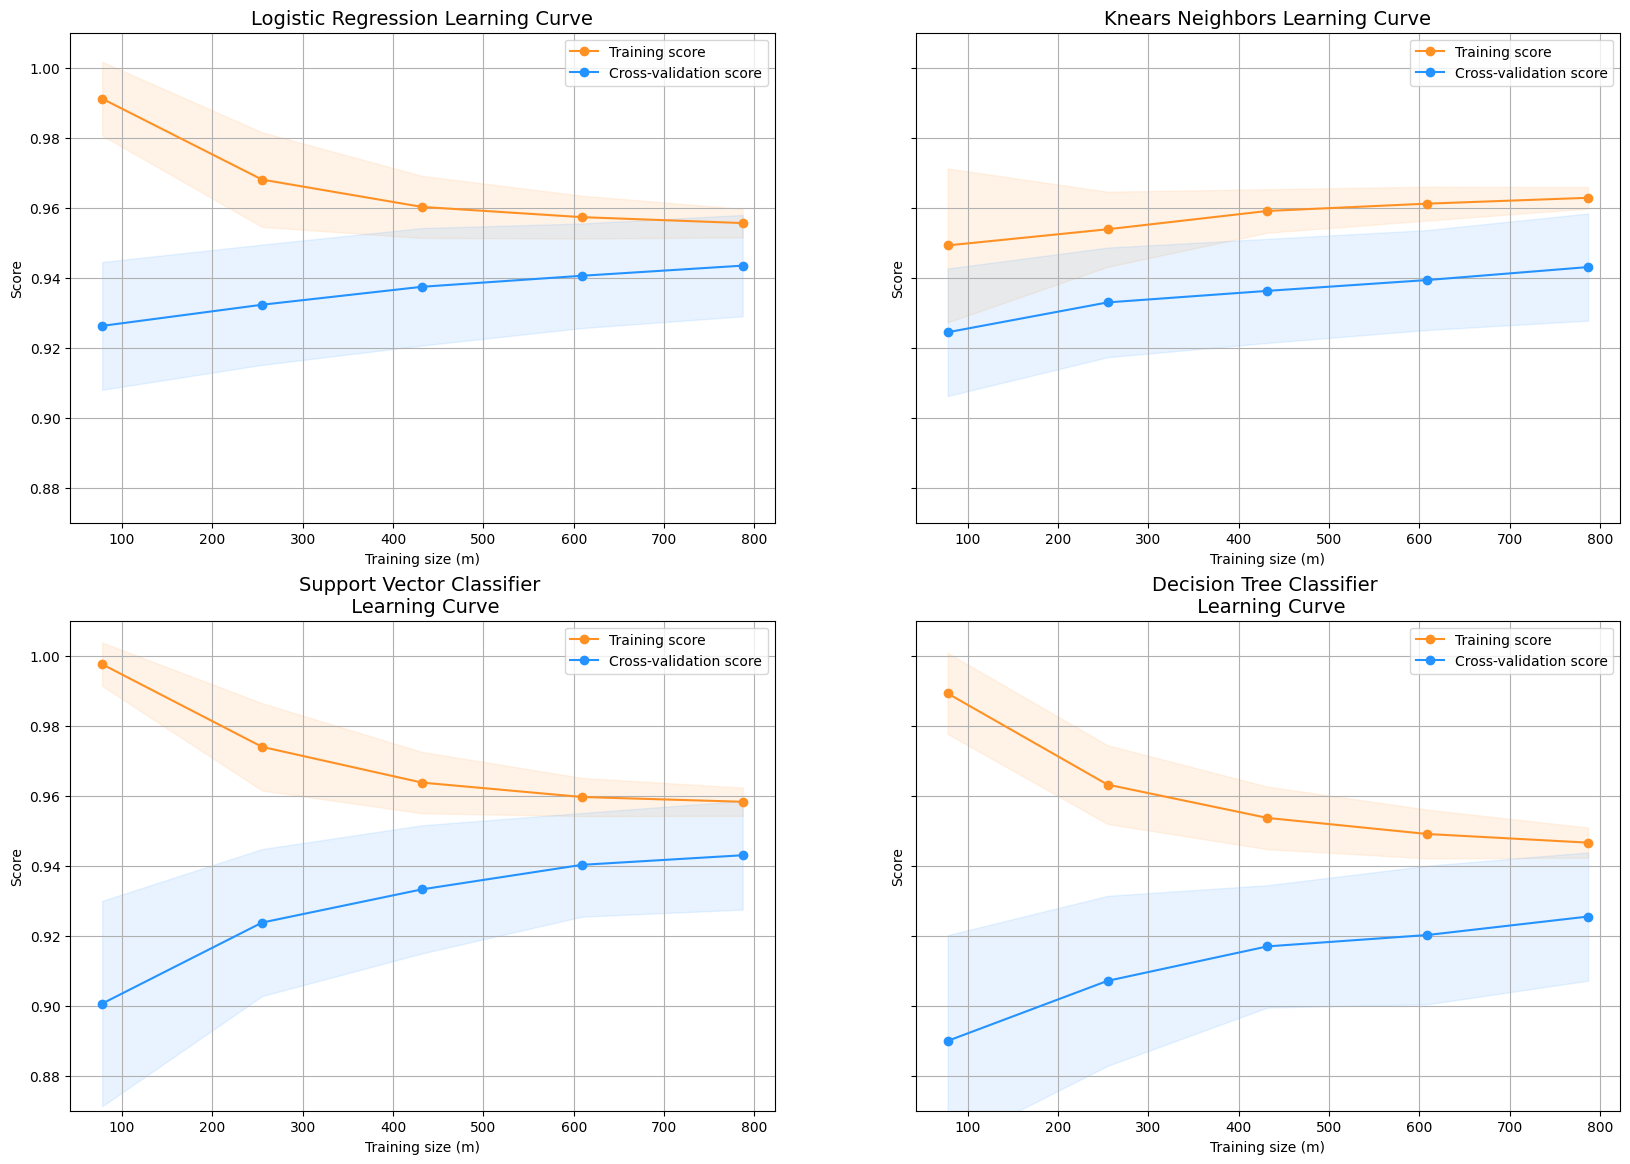

In [ ]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv=cv, n_jobs=4)

In [ ]:
from sklearn.model_selection import cross_val_score

# Calculamos el score para cada clasificador
log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
svc_score = cross_val_score(svc, X_train, y_train, cv=5)
tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)

# Ahora imprimimos el promedio (mean) de esos scores
print('Logistic Regression: ', log_reg_score.mean())
print('KNears Neighbors: ', knears_score.mean())
print('Support Vector Classifier: ', svc_score.mean())
print('Decision Tree Classifier: ', tree_score.mean())

Logistic Regression:  0.9440950999689216
KNears Neighbors:  0.9451103283953175
Support Vector Classifier:  0.9430798715425256
Decision Tree Classifier:  0.926825857246452


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import recall_score

# Creamos el validador de 5 pasos (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_no_supervisados = {"DBSCAN": [], "LOF": []}

# Simulamos la validación cruzada para los no supervisados
for train_index, test_index in kf.split(X_new_scaled):
    # Usamos el pedazo de "test" de cada fold
    X_fold = X_new_scaled[test_index]
    y_fold = y_new[test_index]

    # 1. Validar DBSCAN en este fold
    db_fold = DBSCAN(eps=3.5, min_samples=5).fit_predict(X_fold)
    y_pred_db = np.where(db_fold == -1, 1, 0)
    scores_no_supervisados["DBSCAN"].append(recall_score(y_fold, y_pred_db))

    # 2. Validar LOF en este fold
    lof_fold = LocalOutlierFactor(n_neighbors=20, contamination=0.5)
    y_pred_lof = np.where(lof_fold.fit_predict(X_fold) == -1, 1, 0)
    scores_no_supervisados["LOF"].append(recall_score(y_fold, y_pred_lof))

# Imprimimos resultados comparables a los de Kaggle
print(f"DBSCAN Cross-Val Recall: {np.mean(scores_no_supervisados['DBSCAN']):.4f}")
print(f"LOF Cross-Val Recall: {np.mean(scores_no_supervisados['LOF']):.4f}")

DBSCAN Cross-Val Recall: 0.4959
LOF Cross-Val Recall: 0.6721


In [ ]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict
# Create a DataFrame with all the scores and the classifiers names.

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [ ]:
from sklearn.metrics import roc_auc_score

print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9781586687818097
KNears Neighbors:  0.9451219512195123
Support Vector Classifier:  0.9799928944411395
Decision Tree Classifier:  0.926829268292683


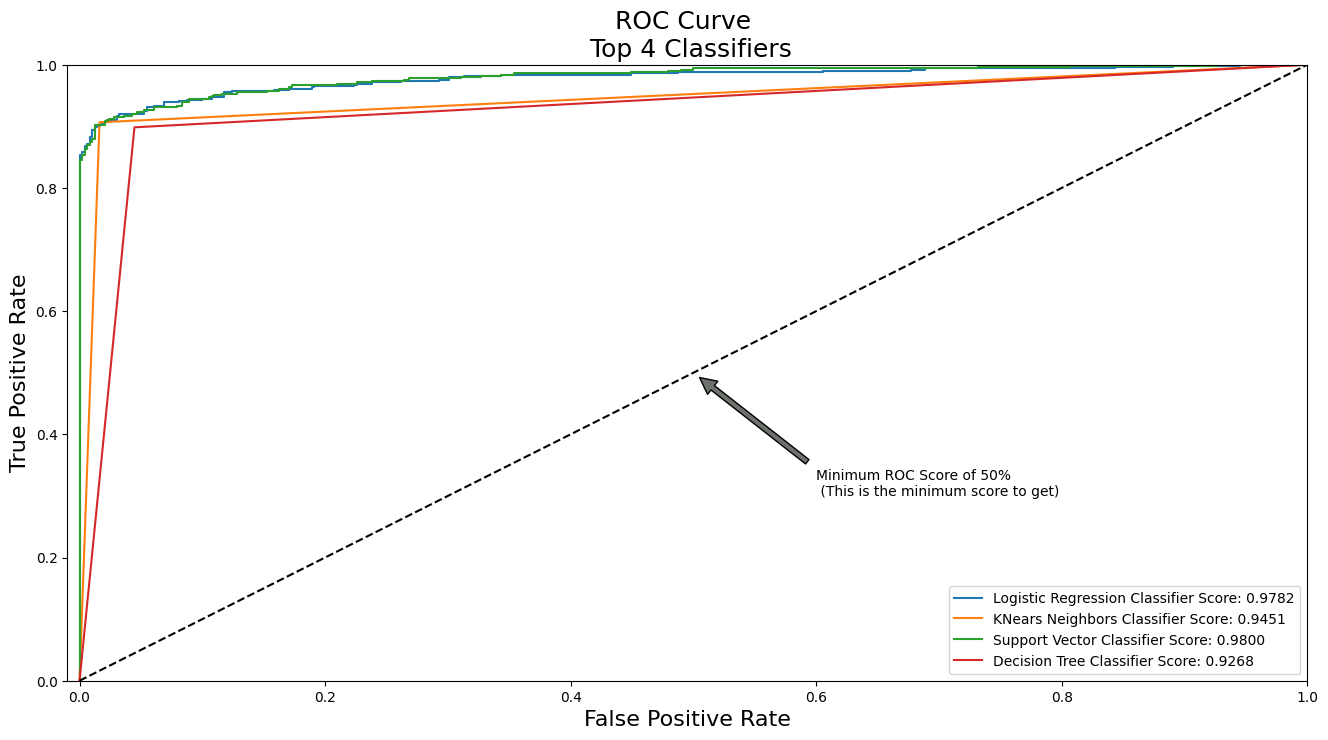

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve \n Top 4 Classifiers', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy=(0.5, 0.5), xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#6E726D', shrink=0.05),
                )
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

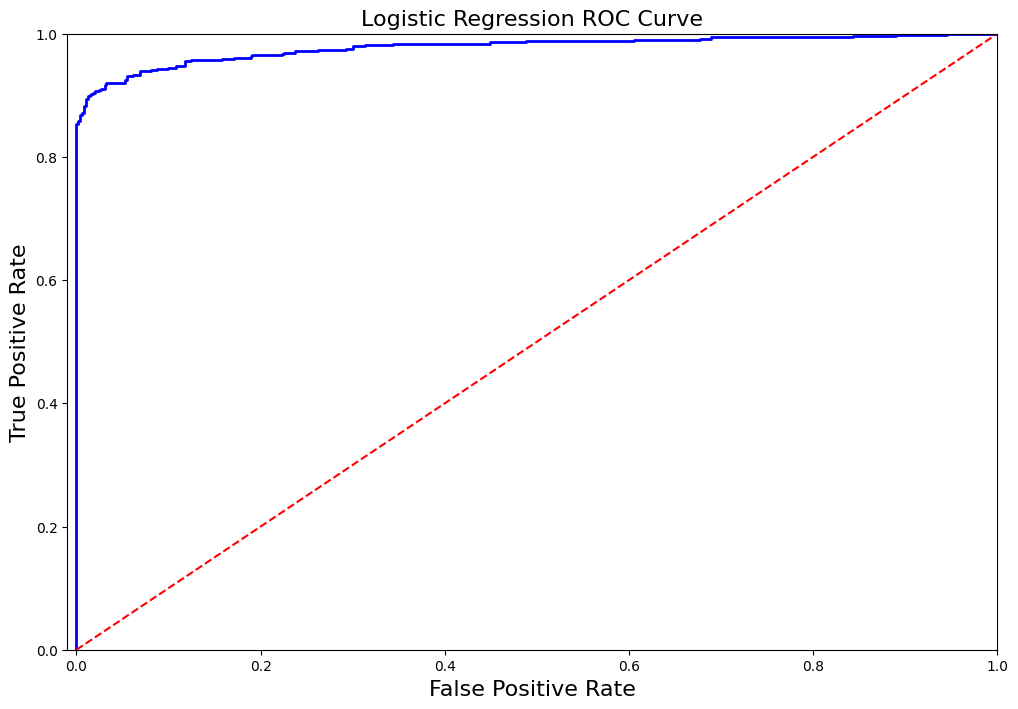

In [ ]:
def logistic_roc_curve(log_fpr, log_tpr):
    plt.figure(figsize=(12,8))
    plt.title('Logistic Regression ROC Curve', fontsize=16)
    plt.plot(log_fpr, log_tpr, 'b-', linewidth=2)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.axis([-0.01,1,0,1])


logistic_roc_curve(log_fpr, log_tpr)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
y_pred = log_reg.predict(X_train)

# Overfitting Case
print('---' * 45)
print('Overfitting: \n')
print('Recall Score: {:.2f}'.format(recall_score(y_train, y_pred)))
print('Precision Score: {:.2f}'.format(precision_score(y_train, y_pred)))
print('F1 Score: {:.2f}'.format(f1_score(y_train, y_pred)))
print('Accuracy Score: {:.2f}'.format(accuracy_score(y_train, y_pred)))
print('---' * 45)

# How it should look like
print('---' * 45)
print('How it should be:\n')
print("Accuracy Score: {:.2f}".format(np.mean(undersample_accuracy)))
print("Precision Score: {:.2f}".format(np.mean(undersample_precision)))
print("Recall Score: {:.2f}".format(np.mean(undersample_recall)))
print("F1 Score: {:.2f}".format(np.mean(undersample_f1)))
print('---' * 45)

---------------------------------------------------------------------------------------------------------------------------------------
Overfitting: 

Recall Score: 0.95
Precision Score: 0.72
F1 Score: 0.82
Accuracy Score: 0.79
---------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------
How it should be:

Accuracy Score: 0.63
Precision Score: 0.00
Recall Score: 0.94
F1 Score: 0.01
---------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
undersample_y_score = log_reg.decision_function(original_Xtest)
print(undersample_y_score)

[28.24761089 17.20331194  0.04746569 ... -0.3146803   1.35907118
 -5.15275571]


In [ ]:

from sklearn.metrics import average_precision_score

undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.69


Text(0.5, 1.0, 'UnderSampling Precision-Recall curve: \n Average Precision-Recall Score =0.69')

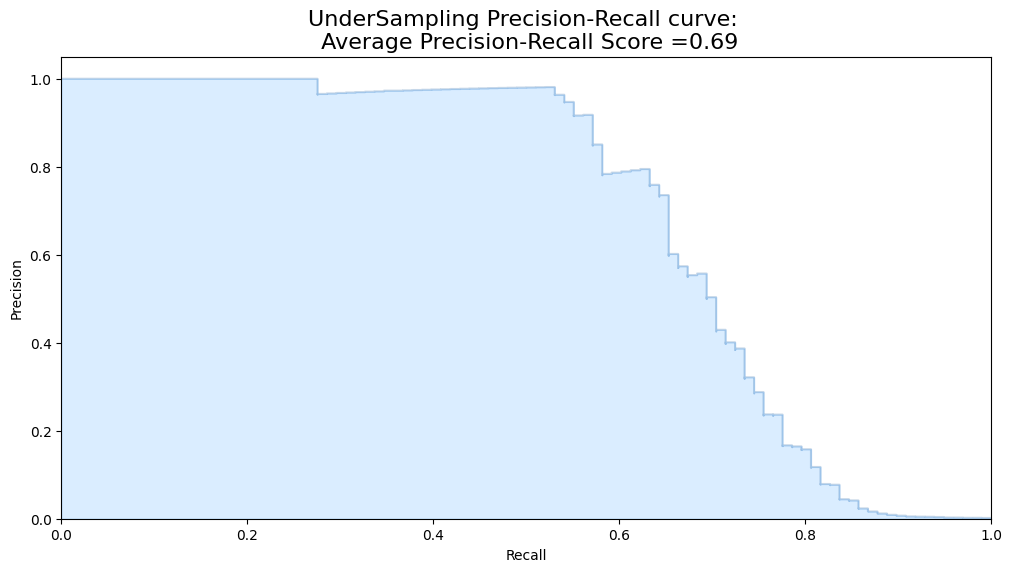

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, undersample_y_score)

plt.step(recall, precision, color='#004a93', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#48a6ff')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('UnderSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          undersample_average_precision), fontsize=16)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV


print('Length of X (train): {} | Length of y (train): {}'.format(len(original_Xtrain), len(original_ytrain)))
print('Length of X (test): {} | Length of y (test): {}'.format(len(original_Xtest), len(original_ytest)))

# List to append the score and then find the average
accuracy_lst = []
precision_lst = []
recall_lst = []
f1_lst = []
auc_lst = []

# Classifier with optimal parameters
# log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm = LogisticRegression()

rand_log_reg = RandomizedSearchCV(LogisticRegression(), log_reg_params, n_iter=4)

# Implementing SMOTE Technique
# Cross Validating the right way
# Parameters
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
for train, test in sss.split(original_Xtrain, original_ytrain):
    pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), rand_log_reg) # SMOTE happens during Cross Validation not before..
    model = pipeline.fit(original_Xtrain[train], original_ytrain[train])
    best_est = rand_log_reg.best_estimator_
    prediction = best_est.predict(original_Xtrain[test])

    accuracy_lst.append(pipeline.score(original_Xtrain[test], original_ytrain[test]))
    precision_lst.append(precision_score(original_ytrain[test], prediction))
    recall_lst.append(recall_score(original_ytrain[test], prediction))
    f1_lst.append(f1_score(original_ytrain[test], prediction))
    auc_lst.append(roc_auc_score(original_ytrain[test], prediction))

print('---' * 45)
print('')
print("accuracy: {}".format(np.mean(accuracy_lst)))
print("precision: {}".format(np.mean(precision_lst)))
print("recall: {}".format(np.mean(recall_lst)))
print("f1: {}".format(np.mean(f1_lst)))
print('---' * 45)

Length of X (train): 227846 | Length of y (train): 227846
Length of X (test): 56961 | Length of y (test): 56961
---------------------------------------------------------------------------------------------------------------------------------------

accuracy: 0.9707479519214901
precision: 0.06460409110228
recall: 0.9137617656604998
f1: 0.11960181712181173
---------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
labels = ['No Fraud', 'Fraud']
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

    No Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.87      0.20        98

    accuracy                           0.99     56961
   macro avg       0.56      0.93      0.59     56961
weighted avg       1.00      0.99      0.99     56961



In [ ]:
y_score = best_est.decision_function(original_Xtest)

In [ ]:
average_precision = average_precision_score(original_ytest, y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

Average precision-recall score: 0.75


Text(0.5, 1.0, 'OverSampling Precision-Recall curve: \n Average Precision-Recall Score =0.75')

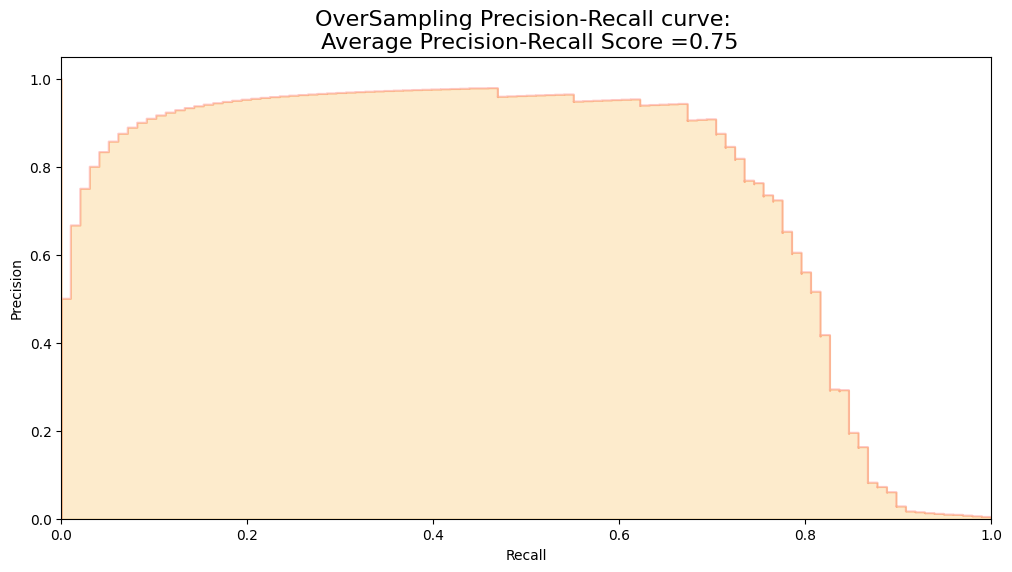

In [ ]:
fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, y_score)

plt.step(recall, precision, color='r', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#F59B00')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('OverSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          average_precision), fontsize=16)

In [ ]:
from imblearn.over_sampling import SMOTE

# 1. Usar sampling_strategy en lugar de ratio
sm = SMOTE(sampling_strategy='minority', random_state=42)

# 2. Usar fit_resample en lugar de fit_sample
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

# Verificamos que funcionó
from collections import Counter
print('Distribución después de SMOTE: {}'.format(Counter(ysm_train)))

Distribución después de SMOTE: Counter({np.int64(0): 227452, np.int64(1): 227452})


In [ ]:
# We Improve the score by 2% points approximately
# Implement GridSearchCV and the other models.

# Logistic Regression
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Fitting oversample data took :{} sec".format(t1 - t0))

Fitting oversample data took :5.097858667373657 sec


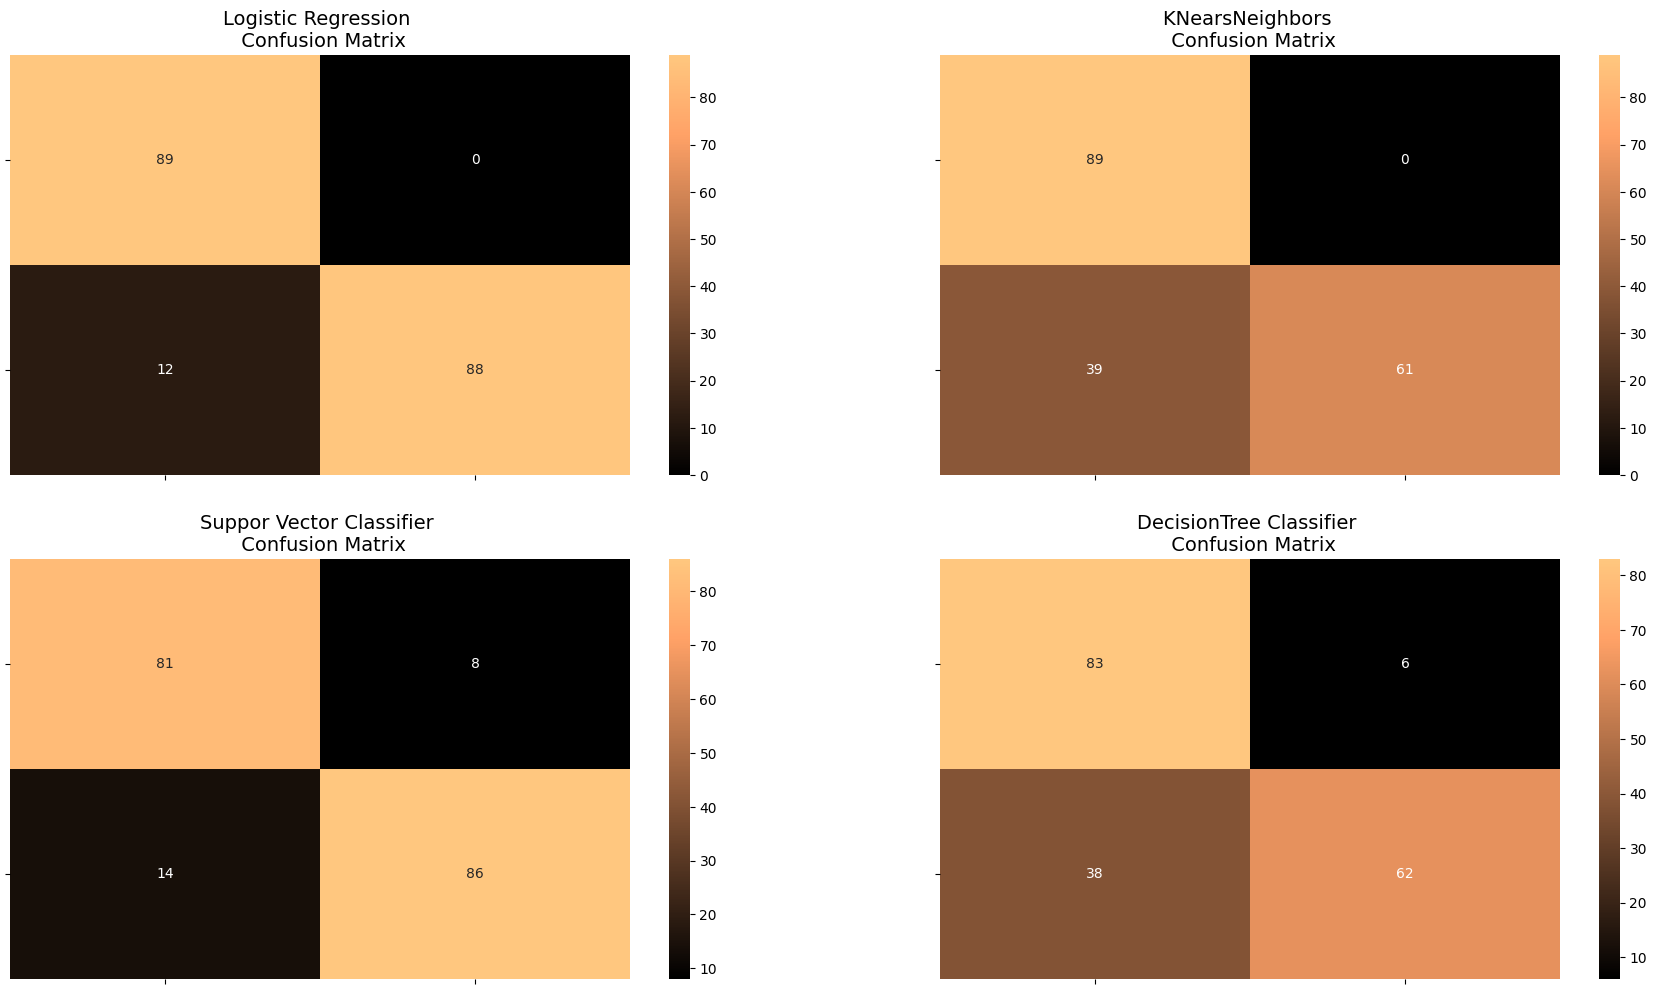

In [ ]:
from sklearn.metrics import confusion_matrix

# Logistic Regression fitted using SMOTE technique
y_pred_log_reg = log_reg_sm.predict(X_test)

# Other models fitted with UnderSampling
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg)
kneighbors_cf = confusion_matrix(y_test, y_pred_knear)
svc_cf = confusion_matrix(y_test, y_pred_svc)
tree_cf = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(2, 2,figsize=(22,12))


sns.heatmap(log_reg_cf, ax=ax[0][0], annot=True, cmap=plt.cm.copper)
ax[0, 0].set_title("Logistic Regression \n Confusion Matrix", fontsize=14)
ax[0, 0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0, 0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(kneighbors_cf, ax=ax[0][1], annot=True, cmap=plt.cm.copper)
ax[0][1].set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)
ax[0][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[0][1].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(svc_cf, ax=ax[1][0], annot=True, cmap=plt.cm.copper)
ax[1][0].set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize=14)
ax[1][0].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][0].set_yticklabels(['', ''], fontsize=14, rotation=360)

sns.heatmap(tree_cf, ax=ax[1][1], annot=True, cmap=plt.cm.copper)
ax[1][1].set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)
ax[1][1].set_xticklabels(['', ''], fontsize=14, rotation=90)
ax[1][1].set_yticklabels(['', ''], fontsize=14, rotation=360)


plt.show()

In [ ]:
from sklearn.metrics import classification_report


print('Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

print('KNears Neighbors:')
print(classification_report(y_test, y_pred_knear))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_svc))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_tree))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        89
           1       1.00      0.88      0.94       100

    accuracy                           0.94       189
   macro avg       0.94      0.94      0.94       189
weighted avg       0.94      0.94      0.94       189

KNears Neighbors:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        89
           1       1.00      0.61      0.76       100

    accuracy                           0.79       189
   macro avg       0.85      0.80      0.79       189
weighted avg       0.86      0.79      0.79       189

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        89
           1       0.91      0.86      0.89       100

    accuracy                           0.88       189
   macro avg       0.88      0.89      0.88       189
weighted

In [ ]:
# Final Score in the test set of logistic regression
from sklearn.metrics import accuracy_score

# Logistic Regression with Under-Sampling
y_pred = log_reg.predict(X_test)
undersample_score = accuracy_score(y_test, y_pred)



# Logistic Regression with SMOTE Technique (Better accuracy with SMOTE t)
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)


d = {'Technique': ['Random UnderSampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

# Move column
score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

# Note how high is accuracy score it can be misleading!
final_df

,Technique,Score
0,Random UnderSampling,0.936508
1,Oversampling (SMOTE),0.987746


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy

# Definir el número de entradas
n_inputs = X_train.shape[1]

# Definir el modelo correctamente
undersample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
]) # <--- Asegúrate de cerrar el corchete y paréntesis

In [ ]:
undersample_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988 (7.77 KB)

 Trainable params: 1,988 (7.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Código corregido
undersample_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
undersample_model.fit(X_train, y_train, validation_split=0.2, batch_size=25, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
32/32 - 2s - 50ms/step - accuracy: 0.6760 - loss: 0.5449 - val_accuracy: 0.8223 - val_loss: 0.4002
Epoch 2/20
32/32 - 0s - 4ms/step - accuracy: 0.9009 - loss: 0.2987 - val_accuracy: 0.8782 - val_loss: 0.3076
Epoch 3/20
32/32 - 0s - 4ms/step - accuracy: 0.9288 - loss: 0.2284 - val_accuracy: 0.8985 - val_loss: 0.2572
Epoch 4/20
32/32 - 0s - 4ms/step - accuracy: 0.9352 - loss: 0.1843 - val_accuracy: 0.9137 - val_loss: 0.2300
Epoch 5/20
32/32 - 0s - 4ms/step - accuracy: 0.9428 - loss: 0.1560 - val_accuracy: 0.9239 - val_loss: 0.2150
Epoch 6/20
32/32 - 0s - 5ms/step - accuracy: 0.9504 - loss: 0.1375 - val_accuracy: 0.9239 - val_loss: 0.2065
Epoch 7/20
32/32 - 0s - 5ms/step - accuracy: 0.9517 - loss: 0.1242 - val_accuracy: 0.9239 - val_loss: 0.1992
Epoch 8/20
32/32 - 0s - 4ms/step - accuracy: 0.9568 - loss: 0.1145 - val_accuracy: 0.9289 - val_loss: 0.1982
Epoch 9/20
32/32 - 0s - 4ms/step - accuracy: 0.9606 - loss: 0.1077 - val_accuracy: 0.9289 - val_loss: 0.1957
Epoch 10/20
32/32 

In [ ]:
undersample_predictions = undersample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [ ]:
import numpy as np

# 1. Obtener las probabilidades (output de la capa softmax)
y_probabilities = undersample_model.predict(original_Xtest, batch_size=200, verbose=0)

# 2. Convertir las probabilidades en la clase con mayor valor (0 o 1)
undersample_fraud_predictions = np.argmax(y_probabilities, axis=1)

# Opcional: Verificar las primeras predicciones
print(undersample_fraud_predictions[:10])

[1 0 0 1 1 0 0 0 0 1]


In [ ]:
import itertools

# Create a confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[52399  4464]
 [   28    70]]
Confusion matrix, without normalization
[[56863     0]
 [    0    98]]


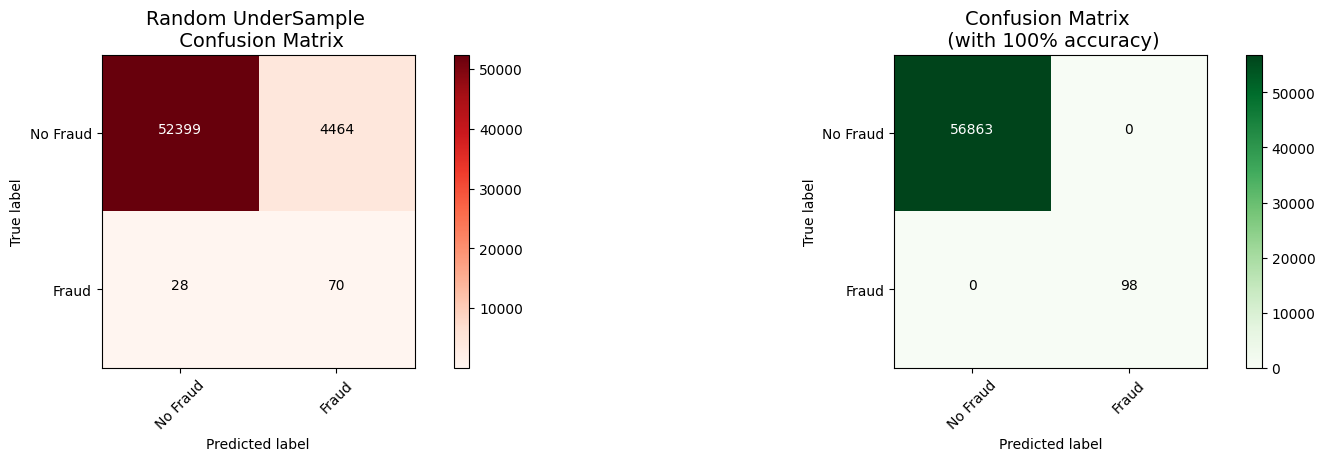

In [ ]:
undersample_cm = confusion_matrix(original_ytest, undersample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig = plt.figure(figsize=(16,8))

fig.add_subplot(221)
plot_confusion_matrix(undersample_cm, labels, title="Random UnderSample \n Confusion Matrix", cmap=plt.cm.Reds)

fig.add_subplot(222)
plot_confusion_matrix(actual_cm, labels, title="Confusion Matrix \n (with 100% accuracy)", cmap=plt.cm.Greens)

In [ ]:
n_inputs = Xsm_train.shape[1]

oversample_model = Sequential([
    Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

In [ ]:
# Cambia 'lr' por 'learning_rate'
oversample_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

oversample_model.fit(Xsm_train, ysm_train, validation_split=0.2, batch_size=300, epochs=20, shuffle=True, verbose=2)

Epoch 1/20
1214/1214 - 4s - 3ms/step - accuracy: 0.9775 - loss: 0.0619 - val_accuracy: 0.9931 - val_loss: 0.0242
Epoch 2/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9964 - loss: 0.0146 - val_accuracy: 0.9998 - val_loss: 0.0075
Epoch 3/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9983 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 4/20
1214/1214 - 4s - 3ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 5/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 6/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 7/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9999 - val_loss: 0.0031
Epoch 8/20
1214/1214 - 3s - 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9996 - val_loss: 0.0043
Epoch 9/20
1214/1214 - 3s - 2ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9999 - 

In [ ]:
oversample_predictions = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)

In [ ]:
import numpy as np

# 1. Obtenemos las probabilidades (salida de la capa softmax)
oversample_probabilities = oversample_model.predict(original_Xtest, batch_size=200, verbose=0)

# 2. Convertimos esas probabilidades a la clase ganadora (0 o 1)
oversample_fraud_predictions = np.argmax(oversample_probabilities, axis=1)

Confusion matrix, without normalization
[[56858     5]
 [   34    64]]
Confusion matrix, without normalization
[[56863     0]
 [    0    98]]


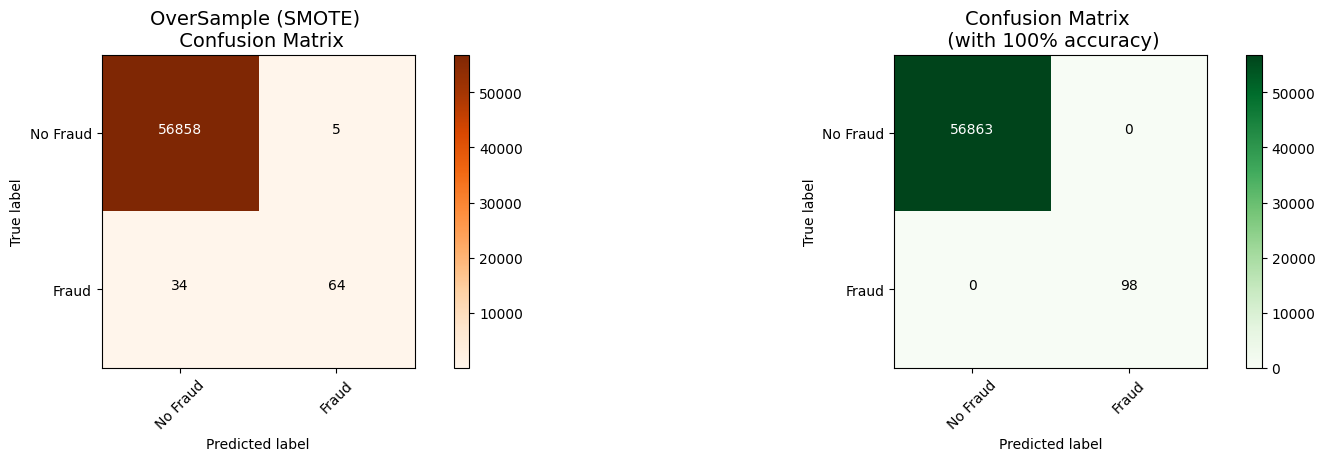

In [ ]:
oversample_smote = confusion_matrix(original_ytest, oversample_fraud_predictions)
actual_cm = confusion_matrix(original_ytest, original_ytest)
labels = ['No Fraud', 'Fraud']

fig = plt.figure(figsize=(16,8))

fig.add_subplot(221)
plot_confusion_matrix(oversample_smote, labels, title="OverSample (SMOTE) \n Confusion Matrix", cmap=plt.cm.Oranges)

fig.add_subplot(222)
plot_confusion_matrix(actual_cm, labels, title="Confusion Matrix \n (with 100% accuracy)", cmap=plt.cm.Greens)

La implementación de SMOTE en nuestro conjunto de datos desequilibrado nos ayudó a corregir el desequilibrio en las etiquetas (más transacciones sin fraude que fraudulentas). Sin embargo, debo mencionar que, en ocasiones, la red neuronal en el conjunto de datos sobremuestreado predice transacciones fraudulentas con menos precisión que nuestro modelo con el conjunto de datos submuestreado. Cabe recordar que la eliminación de valores atípicos se implementó únicamente en el conjunto de datos submuestreado aleatorio, no en el sobremuestreado. Además, en nuestros datos submuestreados, nuestro modelo no detecta correctamente un gran número de transacciones sin fraude y, en cambio, las clasifica erróneamente como fraudulentas. Imaginemos que a personas que realizan compras habituales se les bloquea la tarjeta porque nuestro modelo clasificó la transacción como fraudulenta; esto supondría una gran desventaja para la institución financiera. El número de quejas y la insatisfacción de los clientes aumentarían. El siguiente paso de este análisis consistirá en eliminar los valores atípicos de nuestro conjunto de datos sobremuestreado y comprobar si mejora la precisión en el conjunto de prueba.

Nota: Por último, las predicciones y la precisión podrían variar, ya que implementé la reorganización de datos en ambos tipos de dataframes. Lo importante es comprobar si nuestros modelos son capaces de clasificar correctamente las transacciones fraudulentas y las que no lo son.